# **DATASCI18 (THESIS 2)**
> ***(RF)***
#  
> *Detection and Classification of Panic Attack Occurrence and Severity Using Hybrid Artificial Neural Network and Random Forest (ANN-RF) Model with Explainable Artificial Intelligence (XAI)*

### **FLOW**

### 1. Data Loading
- Import training and testing datasets (`Panic_Disorder_training.csv` and `Panic_Disorder_testing.csv`).
- Verify that the train–test split is balanced by comparing the class distribution of the target variable (Panic Disorder Diagnosis) in both datasets.
---
### 2. Exploratory Data Analysis (EDA)
- Inspect dataset structure (shape, head, column data types).
- Check for missing values
- Visualizations:
  - Histogram and Boxplot for numerical variable
  - Count plots for categorical variables (Gender, Family History, Severity, etc.).
---
### **3. Data Preprocessing and Feature Engineering**
- **Handling Missing Values**
  - Median imputation for numeric columns.  
  - Mode imputation for categorical columns.  
- **Feature Engineering**
  - Drop non-predictive column (`Participant ID`).  
  - Create **Panic Attack Occurrence**, **Panic Attack Occurrence Prob**, **Predicted Severity**, **Severity Confidence**  
  
- **Filtering for Severity Prediction**
  - Subset data to include only samples with `Panic Disorder Diagnosis = 1`.  
  - Apply **Label Encoding** to categorical target variables.  
  - Apply **One-Hot Encoding** for categorical predictors.  
  - Use **Min-Max Scaling** for numeric features to normalize values within [0,1].     
---
### **4. Model Training**
#### **4.1 Random Forest — Occurrence Model**
- **Target Variable:** `Panic Disorder Diagnosis` (binary classification).  
- **Input Features:** Six top predictors — *Medical History, Lifestyle Factors, Symptoms, Current Stressors, Coping Mechanisms, Personal History*.  
- **Configuration:**
  - Parameters: `n_estimators=500`, `max_depth=None`, `max_features='sqrt'`, `min_samples_leaf=12`, `class_weight='balanced'`.  
  - Validation split used for F1-optimized threshold tuning.  
  - Outputs: Accuracy, Precision, Recall, F1-score, ROC-AUC, and training time.  

#### **4.2 Random Forest — Severity Model**
- **Target Variable:** `Severity` (normalized to *Mild, Moderate, Severe*).  
- **Input Features:** Same six features as occurrence (only for `Panic Disorder Diagnosis = 1`).  
- **Configuration:**
  - Multiclass Random Forest classifier with balanced class weights.  
  - Parameters: `n_estimators=400`, `max_depth=None`, `max_features='sqrt'`, `min_samples_leaf=12`, `class_weight='balanced'`.  
  - Outputs: Accuracy, macro-Precision, macro-Recall, macro-F1, macro ROC-AUC, and training time.  
---
### **5. Model Evaluation and Comparison**
- **Performance Metrics:**
  - Accuracy  
  - Precision  
  - Recall  
  - F1-score  
  - ROC-AUC  
- **Visualizations:**
  - Confusion Matrices  
  - ROC Curves  
  - Feature Importance plots  
  - Training time comparison  
---
### **6. Explainable AI (XAI)**
- **Global Interpretability:**  
  - Use **SHAP** to identify which features contribute most to predictions.  
- **Local Interpretability:**  
  - Use **LIME** to explain individual classification decisions.  
- **Key Features Identified:**  
  - *Symptoms, Current Stressors, Psychiatric and Medical History, Lifestyle Factors, and Coping Mechanisms.*  
---

### **DATASET DETAILS:** `Panic Disorder Detection Dataset`

***Data Features (17 columns):***  

- **Participant ID**: Unique identifier assigned to each participant.  
- **Age**: Participant’s age at the time of data collection.  
- **Gender**: Participant’s gender.  
- **Family History**: Presence of panic disorder or other mental health conditions in the participant’s family.  
- **Personal History**: Participant’s past experiences relevant to mental health.  
- **Current Stressors**: Present life stressors that may impact mental health.  
- **Symptoms**: Reported symptoms experienced by the participant.  
- **Severity**: Extent of severity of the reported symptoms.  
- **Impact on Life**: Degree to which symptoms affect daily functioning (work, relationships, etc.).  
- **Demographics**: Participant’s demographic characteristics.  
- **Medical History**: General medical background of the participant.  
- **Psychiatric History**: Participant’s history of psychiatric conditions.  
- **Substance Use**: Information on the participant’s substance use.  
- **Coping Mechanisms**: Strategies employed to manage stress or panic disorder symptoms.  
- **Social Support**: Quantity and quality of social support (family, friends, support groups).  
- **Lifestyle Factors**: Lifestyle aspects (sleep, diet, physical activity) influencing mental health.  
- **Panic Disorder Diagnosis**: Target variable indicating presence or absence of panic disorder.  

### Imports

In [2]:
# Add all necesarry imports
import pandas as pd
import csv
import numpy as np
import csv as reader
import random, time, tensorflow as tf
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler, label_binarize, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve, ConfusionMatrixDisplay
from tensorflow.keras.models import Model
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve, KFold, train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_predict
from imblearn.over_sampling import SMOTE
from scipy.stats import randint
import time
from sklearn.pipeline import Pipeline, make_pipeline

# -------- EXPLAINABLE AI (XAI) --------
# import shap
# import lime
# import lime.lime_tabular
import matplotlib.pyplot as plt
import seaborn as sns
# from lime.lime_tabular import LimeTabularExplainer
# Reproducibility
# np.random.seed(42); random.seed(42); tf.random.set_seed(42)

## ***1. Load the dataset***

## ***Count "None" as Actual Values***

In [3]:
df = pd.read_csv("df.csv")

### Print basic information

In [4]:
print("Dataset Info Training:")
print(df.info())

print("\nDataset Description(including all columns):")
print(df.describe(include='all'))

Dataset Info Training:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10713 entries, 0 to 10712
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Participant ID            10713 non-null  int64 
 1   Age                       10713 non-null  int64 
 2   Gender                    10713 non-null  object
 3   Family History            10713 non-null  object
 4   Personal History          10713 non-null  object
 5   Current Stressors         10713 non-null  object
 6   Symptoms                  10713 non-null  object
 7   Severity                  10713 non-null  object
 8   Impact on Life            10713 non-null  object
 9   Demographics              10713 non-null  object
 10  Medical History           8401 non-null   object
 11  Psychiatric History       8273 non-null   object
 12  Substance Use             7440 non-null   object
 13  Coping Mechanisms         10713 non-null  object
 14 

### Check for missing values and duplicate entries

In [5]:
# Check for missing values in the testing dataset
print("\nMissing values in dataset:")
print(df.isnull().sum())


Missing values in dataset:
Participant ID                 0
Age                            0
Gender                         0
Family History                 0
Personal History               0
Current Stressors              0
Symptoms                       0
Severity                       0
Impact on Life                 0
Demographics                   0
Medical History             2312
Psychiatric History         2440
Substance Use               3273
Coping Mechanisms              0
Social Support                 0
Lifestyle Factors              0
Panic Disorder Diagnosis       0
Composite_Severity_Index       0
Severity_Category              0
dtype: int64


In [6]:
print("Number of Duplicate Rows")
print(df.duplicated().sum())

Number of Duplicate Rows
0


## ***No Actual Empty Values, String "None" are being counted as nan***

In [7]:
# Count the number of "None" entries in the specified columns
columns_to_check = ["Medical History", "Psychiatric History", "Substance Use", "Composite_Severity_Index", "Severity_Category"]

for column in columns_to_check:
    print(f"Unique values in column {column}:")
    print(df[column].unique())
    print("\n")


Unique values in column Medical History:
['Diabetes' 'Asthma' nan 'Heart disease']


Unique values in column Psychiatric History:
[nan 'Depressive disorder' 'Bipolar disorder' 'Anxiety disorder']


Unique values in column Substance Use:
['Drugs' nan 'Alcohol']


Unique values in column Composite_Severity_Index:
[12 14  7 15 10  5 13  8  6  9 11 16  4]


Unique values in column Severity_Category:
['Moderately ill' 'Markedly ill' 'Mildly ill' 'Borderline ill']




## ***Count "None" as Actual Values***

In [8]:
df = pd.read_csv("df.csv", na_values=["", " "], keep_default_na=False)

## ***2. Exploratory Data Analysis (EDA)***

In [9]:
# Inspect dataset structure
print("Dataset shape:", df.shape)

print("\nDataset info:")
print(df.info())

Dataset shape: (10713, 19)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10713 entries, 0 to 10712
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Participant ID            10713 non-null  int64 
 1   Age                       10713 non-null  int64 
 2   Gender                    10713 non-null  object
 3   Family History            10713 non-null  object
 4   Personal History          10713 non-null  object
 5   Current Stressors         10713 non-null  object
 6   Symptoms                  10713 non-null  object
 7   Severity                  10713 non-null  object
 8   Impact on Life            10713 non-null  object
 9   Demographics              10713 non-null  object
 10  Medical History           8401 non-null   object
 11  Psychiatric History       8273 non-null   object
 12  Substance Use             7440 non-null   object
 13  Coping Mechanisms         10713 no

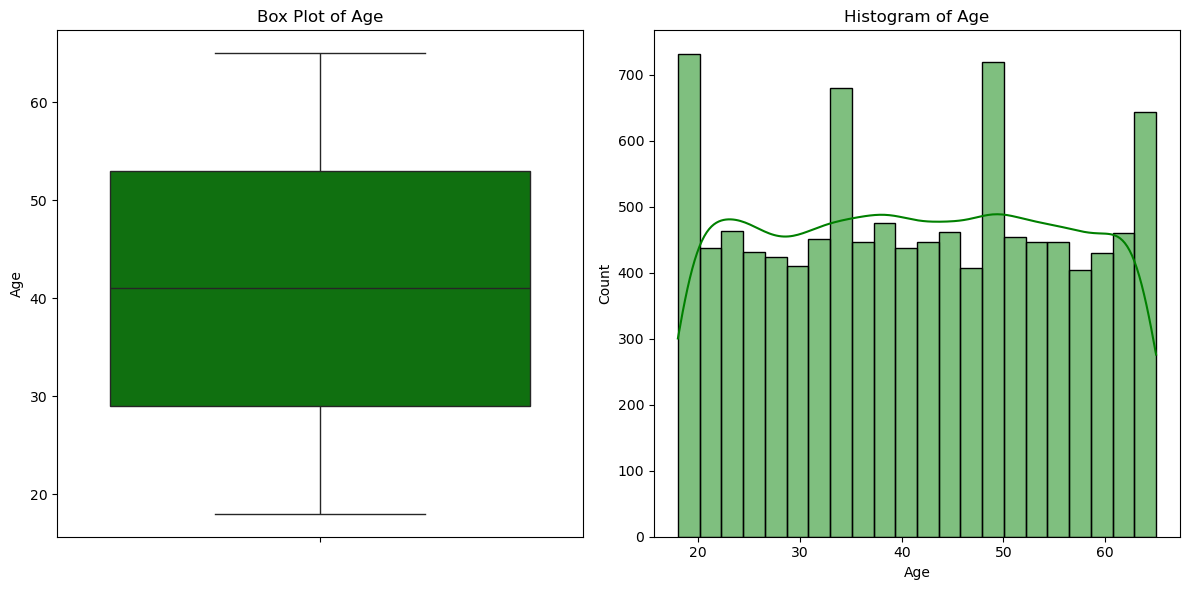

In [10]:
# Visualizations
# Histogram and Boxplot for numerical variable (Age)
feature = "Age"
plt.figure(figsize=(12, 6))

# Box Plot
plt.subplot(1, 2, 1)
sns.boxplot(y=df[feature], color="green")
plt.title('Box Plot of Age')

# Histogram with KDE
plt.subplot(1, 2, 2)
sns.histplot(data=df, x=feature, kde=True, color="green")
plt.title('Histogram of Age')
plt.tight_layout()
plt.show()

C:\Users\Moko_\AppData\Local\Temp\ipykernel_12132\3612807590.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, palette="Greens", ax=ax)
C:\Users\Moko_\AppData\Local\Temp\ipykernel_12132\3612807590.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, palette="Greens", ax=ax)
C:\Users\Moko_\AppData\Local\Temp\ipykernel_12132\3612807590.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, palette="Greens", ax=ax)
C:\Users\Moko_\AppData\Local\Temp\ipykernel_12132\3612807590.py:

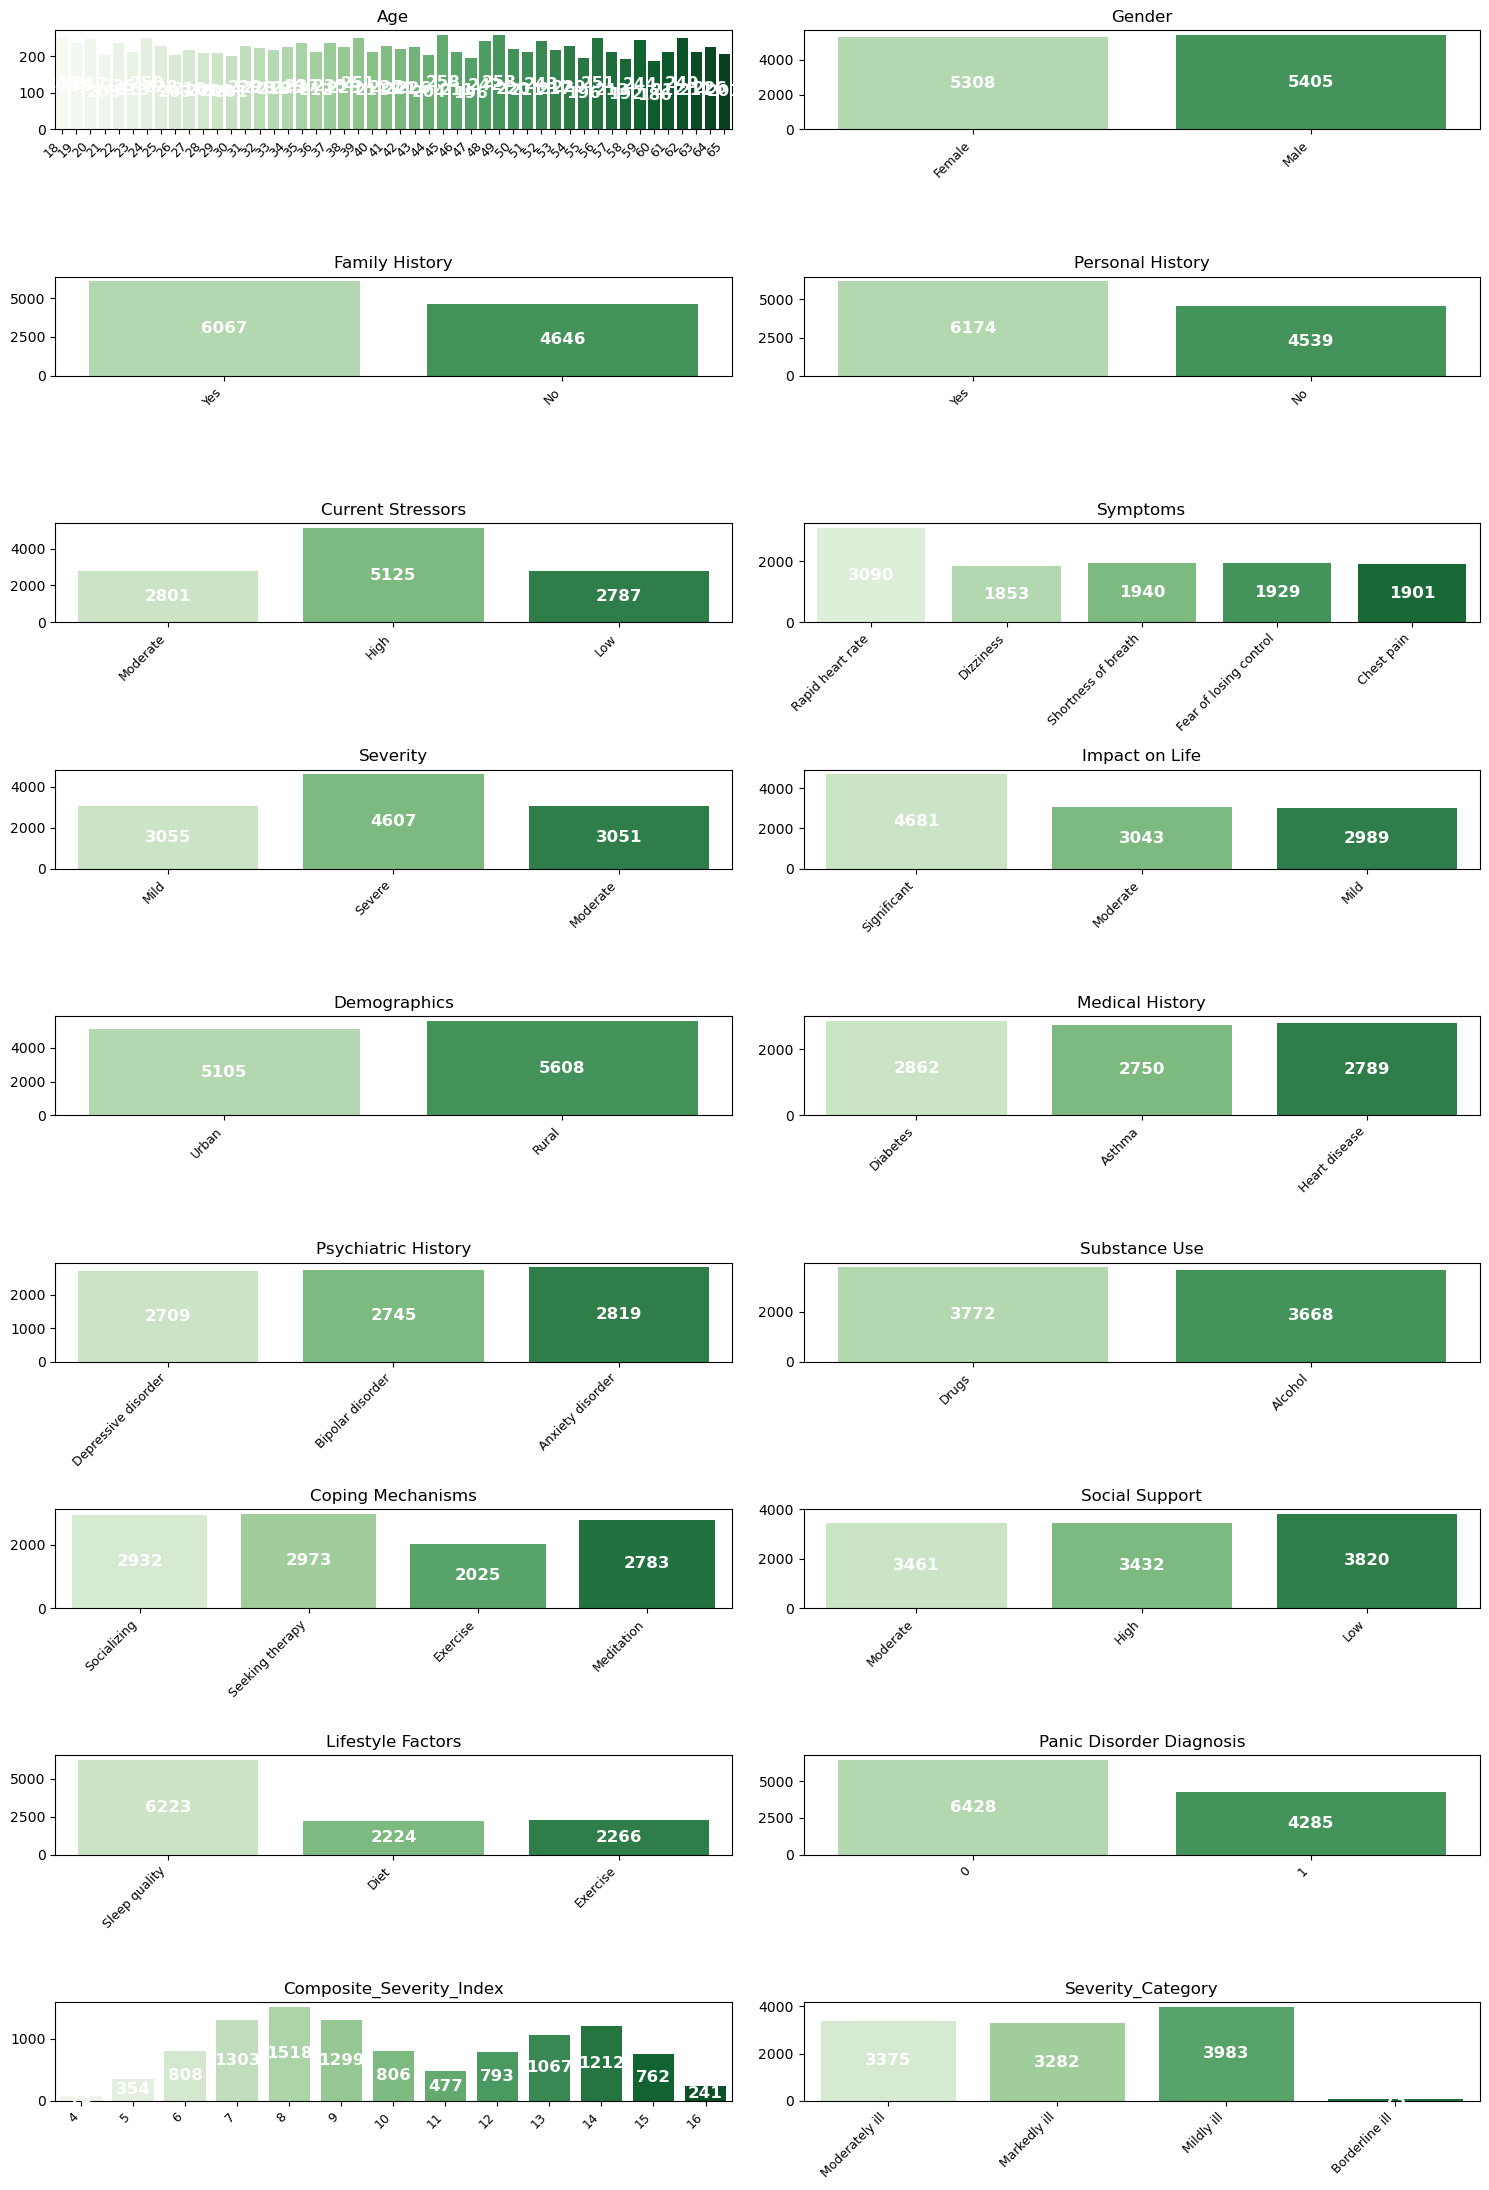

In [11]:
# Bar Plots of ALL Categorical Features (except ID, Age, Panic Disorder Diagnosis)
selected_columns = [
    col for col in df.columns
    if col not in ["Participant ID"]
]

plt.figure(figsize=(15, 22))

for i, feature in enumerate(selected_columns):
    ax = plt.subplot(9, 2, i+1)
    sns.countplot(data=df, x=feature, palette="Greens", ax=ax)
    plt.xticks(rotation=45, ha="right", fontsize=9)
    plt.xlabel('')
    plt.ylabel('')
    plt.title(feature, fontsize=12)

    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='center', fontsize=12, color='white', weight='bold')

plt.tight_layout()
plt.show()

## ***3. Data Preprocessing***

In [12]:
# Handling Missing Values
# Check for missing values in the dataset
print("Missing values in dataset:")
print(df.isnull().sum())

Missing values in dataset:
Participant ID                 0
Age                            0
Gender                         0
Family History                 0
Personal History               0
Current Stressors              0
Symptoms                       0
Severity                       0
Impact on Life                 0
Demographics                   0
Medical History             2312
Psychiatric History         2440
Substance Use               3273
Coping Mechanisms              0
Social Support                 0
Lifestyle Factors              0
Panic Disorder Diagnosis       0
Composite_Severity_Index       0
Severity_Category              0
dtype: int64


> `NOTE:` Since there are no missing values, handling of missing values will be skipped

In [13]:
# ==================== 2. Feature Engineering & Pre-Encoding ====================

# 1) Drop Participant ID
if 'Participant ID' in df.columns:
    df.drop(columns=['Participant ID'], inplace=True)
    print("Dropped 'Participant ID'.")

# 2) Define placeholder/variable names
DIAGNOSIS_COL = "Panic Disorder Diagnosis"
PAO_LABEL_COL = "Panic Attack Occurrence"
PAO_PROBA_COL = "Panic Attack Occurrence Probability"

PAS_PROBA_COL = "Panic Attack Severity Probability"

#Feature Engineered Column
PAS_LABEL_COL = "Panic Attack Severity" # This is the only feature engineered column as we will map the "Severity_Category" to make this the target variable for predicting panic attack severity

# 3) Create placeholder columns
for col in [PAO_LABEL_COL, PAO_PROBA_COL, PAS_PROBA_COL]:
    if col not in df.columns:
        df[col] = pd.Series([pd.NA] * len(df), dtype="Float64")
        
# Special handling for the Int64 target
if PAS_LABEL_COL not in df.columns:
    df[PAS_LABEL_COL] = pd.Series([pd.NA] * len(df), dtype="Int64")
        
print(f"Created placeholder columns: {PAO_LABEL_COL}, {PAS_LABEL_COL}, etc.")

# 4) Create the Target Variable 'Panic Attack Severity'
print(f"Populating target variable: '{PAS_LABEL_COL}'")
severity_mapping = {
    'Borderline ill': 1,  # Mild
    'Mildly ill': 1,      # Mild
    'Moderately ill': 2,  # Moderate
    'Markedly ill': 3      # Severe
}
df[PAS_LABEL_COL] = df['Severity_Category'].map(severity_mapping)
print(f"Mapped severity strings to '{PAS_LABEL_COL}'.")
print(df[PAS_LABEL_COL].value_counts(dropna=False).sort_index())

Dropped 'Participant ID'.
Created placeholder columns: Panic Attack Occurrence, Panic Attack Severity, etc.
Populating target variable: 'Panic Attack Severity'
Mapped severity strings to 'Panic Attack Severity'.
Panic Attack Severity
1    4056
2    3375
3    3282
Name: count, dtype: int64


In [14]:
# ==================== 3. Create Train/Test Split ====================
print("\nCreating train/test split...")

# We will stratify on the *new target variable* for balanced splits
train_df, test_df = train_test_split(
    df, 
    test_size=0.2, 
    random_state=42, 
    stratify=df[PAS_LABEL_COL]  # Stratify on our new 1, 2, 3 target
)

print(f"Created train_df with shape: {train_df.shape}")
print(f"Created test_df with shape: {test_df.shape}")

print("\n--- Train/Test Split Verification (Target Distribution) ---")
print("\nTraining Set:")
print(train_df[PAS_LABEL_COL].value_counts(normalize=True).sort_index())
print("\nTest Set:")
print(test_df[PAS_LABEL_COL].value_counts(normalize=True).sort_index())


Creating train/test split...
Created train_df with shape: (8570, 22)
Created test_df with shape: (2143, 22)

--- Train/Test Split Verification (Target Distribution) ---

Training Set:
Panic Attack Severity
1    0.378646
2    0.315053
3    0.306301
Name: proportion, dtype: float64

Test Set:
Panic Attack Severity
1    0.378441
2    0.314979
3    0.306580
Name: proportion, dtype: float64


### Check class imbalance of target variables

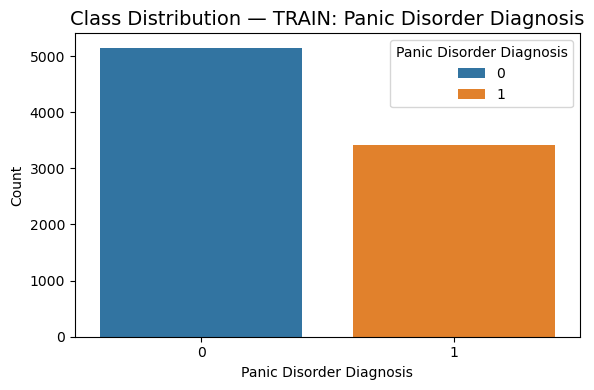

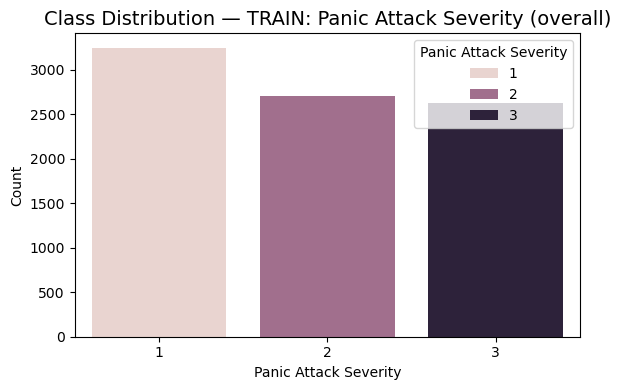

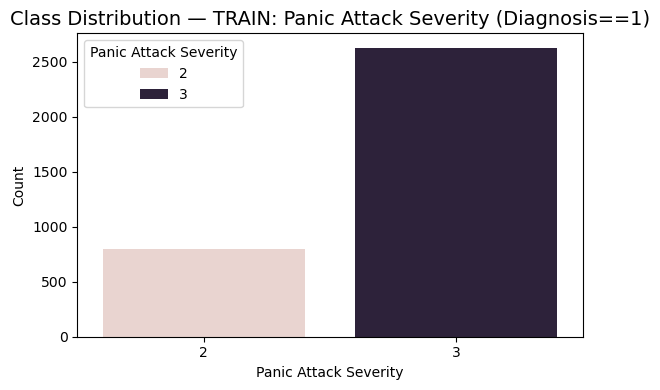

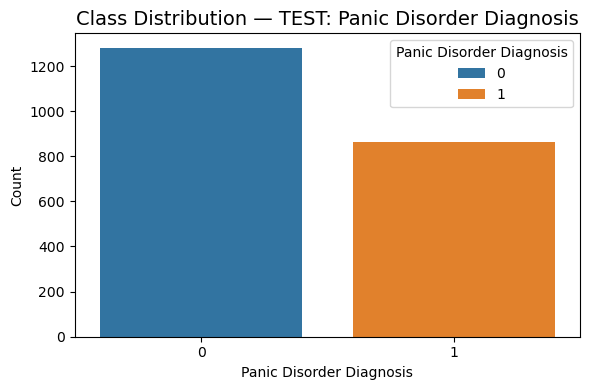

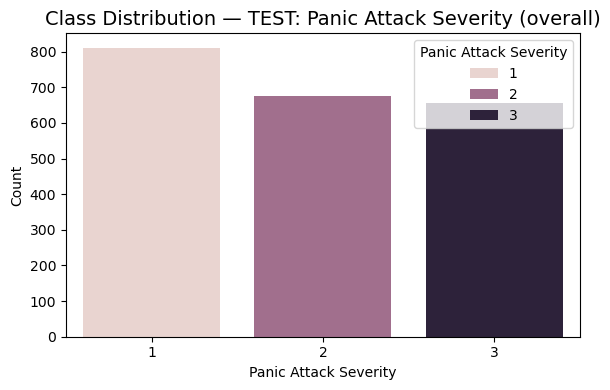

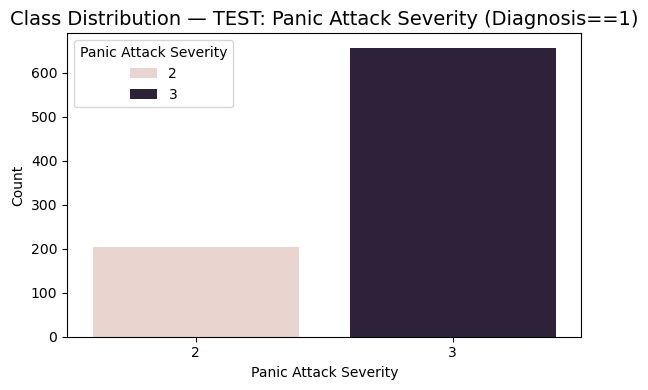

In [15]:
# =========================
# Visualizations (targets) - CORRECTED
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

# NOTE: This cell assumes the previous cells have been run, so
# 'train_df', 'test_df', 'DIAGNOSIS_COL', and 'PAS_LABEL_COL' already exist.

def plot_count(df, col, title, order=None):
    """
    Plotting function, fixed to use plt.show() and remove errors.
    """
    plt.figure(figsize=(6, 4))
    if order is None:
        order = sorted(pd.unique(df[col].dropna()))
    
    sns.countplot(
        data=df,
        x=col,
        hue=col,
        order=order,
        hue_order=order,
        # legend=False  <-- This argument is invalid and has been removed.
    )
    plt.title(title, fontsize=14)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(ticks=range(len(order)), labels=[str(v) for v in order], rotation=0)
    plt.tight_layout()
    plt.show() # FIX: Display the plot instead of saving

# ---- TRAIN ----
# Panic Disorder Diagnosis (0/1)
plot_count(
    train_df, 
    col=DIAGNOSIS_COL,
    title="Class Distribution — TRAIN: Panic Disorder Diagnosis",
    order=[0, 1]
)

# Panic Attack Severity overall (mapped to {1,2,3})
plot_count(
    train_df, 
    col=PAS_LABEL_COL, # FIX: Use your correct target variable
    title=f"Class Distribution — TRAIN: {PAS_LABEL_COL} (overall)",
    order=[1, 2, 3] # Order is {1, 2, 3}
)

# Panic Attack Severity for diagnosed==1 only (binary {2,3})
plot_count(
    train_df.loc[train_df[DIAGNOSIS_COL] == 1],
    col=PAS_LABEL_COL, # FIX: Use your correct target variable
    title=f"Class Distribution — TRAIN: {PAS_LABEL_COL} (Diagnosis==1)",
    order=[2, 3] # Correct, as '1' (Mild) does not exist here
)

# ---- TEST ----
plot_count(
    test_df, 
    col=DIAGNOSIS_COL,
    title="Class Distribution — TEST: Panic Disorder Diagnosis",
    order=[0, 1]
)

plot_count(
    test_df, 
    col=PAS_LABEL_COL, # FIX: Use your correct target variable
    title=f"Class Distribution — TEST: {PAS_LABEL_COL} (overall)",
    order=[1, 2, 3] # Order is {1, 2, 3}
)

plot_count(
    test_df.loc[test_df[DIAGNOSIS_COL] == 1],
    col=PAS_LABEL_COL, # FIX: Use your correct target variable
    title=f"Class Distribution — TEST: {PAS_LABEL_COL} (Diagnosis==1)",
    order=[2, 3] # Correct
)

### Visualize Class Imbalance

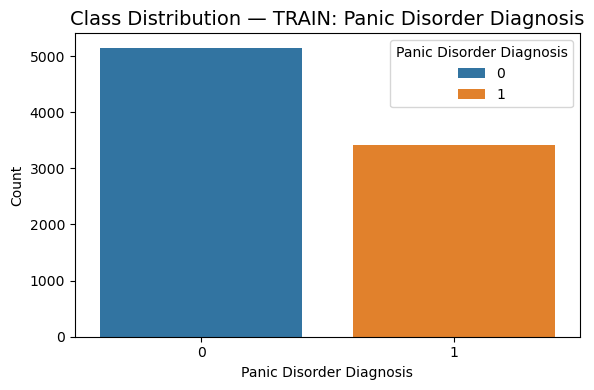

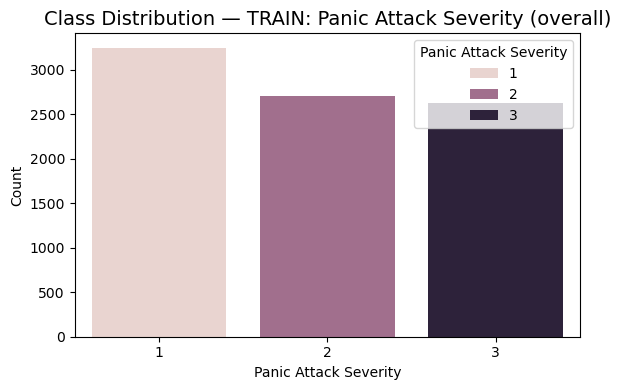

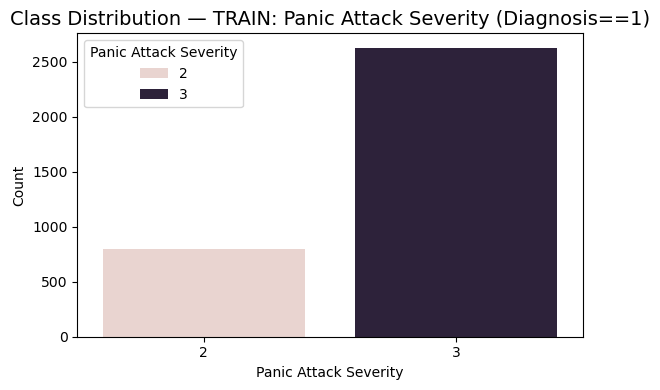

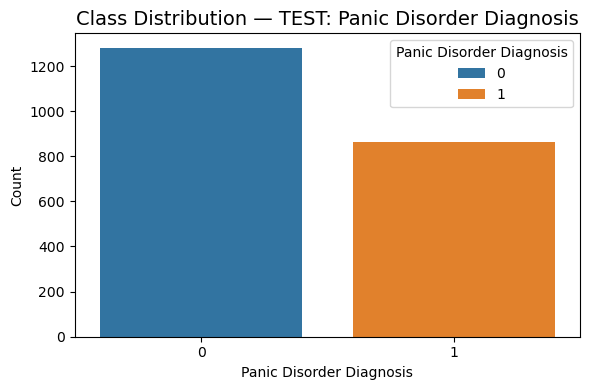

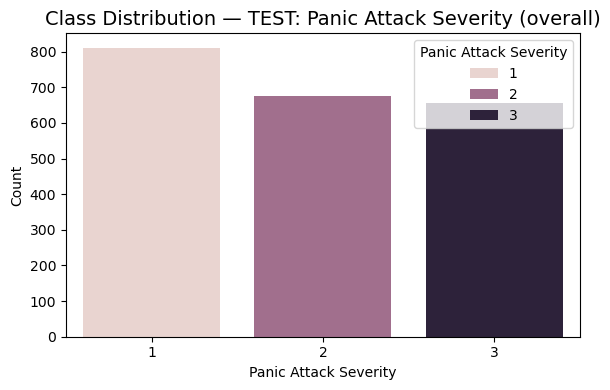

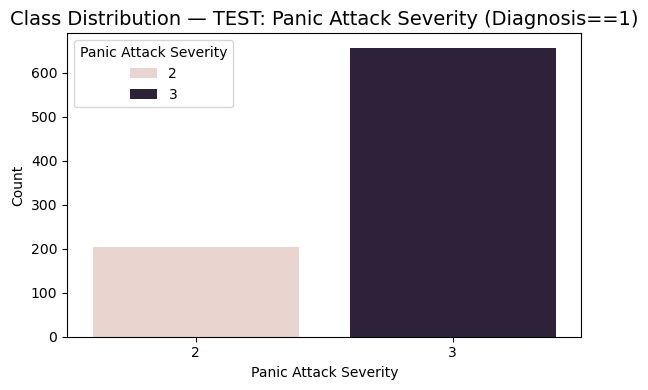

In [16]:
# =========================
# Visualizations (targets) - CORRECTED
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

# NOTE: This cell assumes the previous cells have been run, so
# 'train_df', 'test_df', 'DIAGNOSIS_COL', and 'PAS_LABEL_COL' already exist.

def plot_count(df, col, title, order=None):
    """
    Plotting function, fixed to use plt.show() and remove errors.
    """
    plt.figure(figsize=(6, 4))
    if order is None:
        order = sorted(pd.unique(df[col].dropna()))
    
    sns.countplot(
        data=df,
        x=col,
        hue=col,
        order=order,
        hue_order=order,
        # legend=False  <-- This argument is invalid and has been removed.
    )
    plt.title(title, fontsize=14)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(ticks=range(len(order)), labels=[str(v) for v in order], rotation=0)
    plt.tight_layout()
    plt.show() # FIX: Display the plot instead of saving

# ---- TRAIN ----
# Panic Disorder Diagnosis (0/1)
plot_count(
    train_df, 
    col=DIAGNOSIS_COL,
    title="Class Distribution — TRAIN: Panic Disorder Diagnosis",
    order=[0, 1]
)

# Panic Attack Severity overall (mapped to {1,2,3})
plot_count(
    train_df, 
    col=PAS_LABEL_COL, # FIX: Use your correct target variable
    title=f"Class Distribution — TRAIN: {PAS_LABEL_COL} (overall)",
    order=[1, 2, 3] # Order is {1, 2, 3}
)

# Panic Attack Severity for diagnosed==1 only (binary {2,3})
plot_count(
    train_df.loc[train_df[DIAGNOSIS_COL] == 1],
    col=PAS_LABEL_COL, # FIX: Use your correct target variable
    title=f"Class Distribution — TRAIN: {PAS_LABEL_COL} (Diagnosis==1)",
    order=[2, 3] # Correct, as '1' (Mild) does not exist here
)

# ---- TEST ----
plot_count(
    test_df, 
    col=DIAGNOSIS_COL,
    title="Class Distribution — TEST: Panic Disorder Diagnosis",
    order=[0, 1]
)

plot_count(
    test_df, 
    col=PAS_LABEL_COL, # FIX: Use your correct target variable
    title=f"Class Distribution — TEST: {PAS_LABEL_COL} (overall)",
    order=[1, 2, 3] # Order is {1, 2, 3}
)

plot_count(
    test_df.loc[test_df[DIAGNOSIS_COL] == 1],
    col=PAS_LABEL_COL, # FIX: Use your correct target variable
    title=f"Class Distribution — TEST: {PAS_LABEL_COL} (Diagnosis==1)",
    order=[2, 3] # Correct
)

### Encoding & Class Normalization

In [17]:
# ==================== OCCURRENCE TASK: encode all non-target features ====================
# This code assumes 'train_df', 'test_df', and the placeholder column names 
# (e.g., PAS_LABEL_COL, PAO_LABEL_COL) are already in memory from previous cells.
#
# We will create X_train_occ_enc and X_test_occ_enc for the "Occurrence" model.

# Targets (binary for occurrence)
y_train_occ = train_df['Panic Disorder Diagnosis'].astype(int)
y_test_occ  = test_df['Panic Disorder Diagnosis'].astype(int)

# This is the FIXED (non-leaking) code
EXCLUDE_OCC = {
    'Panic Disorder Diagnosis',     # occurrence target
    
    # Placeholder/Output Columns (not features)
    PAO_LABEL_COL, PAO_PROBA_COL,   
    PAS_LABEL_COL, PAS_PROBA_COL,   
    
    # Leaky/Redundant Features (from your original list)
    'Severity',
    'Impact on Life',
    'Severity_num',
    'Impact on Life_num',
    'Symptoms',
    
    # --- ADDED AS REQUESTED ---
    'Composite_Severity_Index',
    'Severity_Category'
}

# Use the train columns as the canonical feature set; align test to it
FEATURE_COLS = [c for c in train_df.columns if c not in EXCLUDE_OCC]

X_train_occ = train_df[FEATURE_COLS].copy()
X_test_occ  = test_df.reindex(columns=FEATURE_COLS).copy()  # ensures same columns/order

# Infer types: numeric vs categorical
num_cols_occ = list(X_train_occ.select_dtypes(include=['number']).columns)
cat_cols_occ = [c for c in FEATURE_COLS if c not in num_cols_occ]

# Version-safe OneHotEncoder
def _make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

# No imputation (keep data unmodified); Age has no missings, pass through
numeric_pipe = "passthrough"
categorical_pipe = _make_ohe()

# ColumnTransformer
transformers = []
if num_cols_occ:
    transformers.append(("num", numeric_pipe, num_cols_occ))
if cat_cols_occ:
    transformers.append(("cat", categorical_pipe, cat_cols_occ))

if not transformers:
    raise ValueError("[OCC] No valid feature columns found. Check exclusions and dataset columns.")

pre_occ = ColumnTransformer(transformers, remainder="drop")

# ==== FIT ONLY ON TRAIN; TRANSFORM BOTH ====
X_train_occ_enc = pre_occ.fit_transform(X_train_occ)
X_test_occ_enc  = pre_occ.transform(X_test_occ)

# --- Print Summary ---
print("[OCC] excluded (targets/outputs):", sorted(EXCLUDE_OCC & set(train_df.columns)))
print("[OCC] numeric columns:", num_cols_occ if num_cols_occ else "None")
print("[OCC] categorical columns:", cat_cols_occ if cat_cols_occ else "None")
print("[OCC] shapes → train:", X_train_occ_enc.shape, " test:", X_test_occ_enc.shape)
print("[OCC] y_train base rate:", float(y_train_occ.mean()))

# Retrieve the feature names from the ColumnTransformer
try:
    feature_names = pre_occ.get_feature_names_out()
    
    # Convert the encoded numpy arrays into DataFrames
    train_encoded_df = pd.DataFrame(X_train_occ_enc, columns=feature_names)
    test_encoded_df  = pd.DataFrame(X_test_occ_enc,  columns=feature_names)
    
    # Optionally, add back the target column(s) for reference
    train_encoded_df['Panic_Disorder_Diagnosis'] = y_train_occ.values
    test_encoded_df['Panic_Disorder_Diagnosis']  = y_test_occ.values
    
    # Save to CSV
    train_encoded_df.to_csv("train_onehot_occ.csv", index=False)
    test_encoded_df.to_csv("test_onehot_occ.csv", index=False)
    
    print("\n✅ Encoded CSVs saved as train_onehot_occ.csv and test_onehot_occ.csv")
    
except Exception as e:
    print(f"\nCould not get feature names or save CSVs. Error: {e}")
    print("The encoded arrays 'X_train_occ_enc' and 'X_test_occ_enc' are still ready for modeling.")

[OCC] excluded (targets/outputs): ['Composite_Severity_Index', 'Impact on Life', 'Panic Attack Occurrence', 'Panic Attack Occurrence Probability', 'Panic Attack Severity', 'Panic Attack Severity Probability', 'Panic Disorder Diagnosis', 'Severity', 'Severity_Category', 'Symptoms']
[OCC] numeric columns: ['Age']
[OCC] categorical columns: ['Gender', 'Family History', 'Personal History', 'Current Stressors', 'Demographics', 'Medical History', 'Psychiatric History', 'Substance Use', 'Coping Mechanisms', 'Social Support', 'Lifestyle Factors']
[OCC] shapes → train: (8570, 33)  test: (2143, 33)
[OCC] y_train base rate: 0.39941656942823806

✅ Encoded CSVs saved as train_onehot_occ.csv and test_onehot_occ.csv


## ***4. Model Training***

### ------***Hybrid Artificial Neural Network - Random Forest (ANN - RF) - Occurrence Model***------

# HYBRID OCCURRENCE 1: ANN (Tuned Best Params) -> RF (Baseline)

✅ OCCURRENCE VARIABLES READY (Tuned ANN + Base RF):
   ANN Input: (8570, 33)
   RF Target: (8570,)

Starting 10-Fold CV on ANN Classifier Only...

Fold 1/10 complete (ANN Only).
Fold 2/10 complete (ANN Only).
Fold 3/10 complete (ANN Only).
Fold 4/10 complete (ANN Only).
Fold 5/10 complete (ANN Only).
Fold 6/10 complete (ANN Only).
Fold 7/10 complete (ANN Only).
Fold 8/10 complete (ANN Only).
Fold 9/10 complete (ANN Only).
Fold 10/10 complete (ANN Only).

Starting 10-Fold CV on HYBRID (ANN Feature Extractor + RF)...


c:\Users\Moko_\anaconda3\envs\panicml\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\Moko_\anaconda3\envs\panicml\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Fold 1/10 complete (Hybrid ANN+RF). Acc=0.9172, F1=0.9004, AUC=0.9716


c:\Users\Moko_\anaconda3\envs\panicml\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\Moko_\anaconda3\envs\panicml\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Fold 2/10 complete (Hybrid ANN+RF). Acc=0.9078, F1=0.8922, AUC=0.9616


...

c:\Users\Moko_\anaconda3\envs\panicml\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\Moko_\anaconda3\envs\panicml\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Fold 9/10 complete (Hybrid ANN+RF). Acc=0.9265, F1=0.9124, AUC=0.9738


c:\Users\Moko_\anaconda3\envs\panicml\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\Moko_\anaconda3\envs\panicml\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Fold 10/10 complete (Hybrid ANN+RF). Acc=0.9148, F1=0.8996, AUC=0.9682

[H2] Hybrid ANN+RF — Per-Fold Metrics (10-Fold CV on Training Set):
       model_name  fold_id  accuracy  precision   recall       f1  roc_auc  n_val_samples
Hybrid_ANN_RF_occ        1  0.917153   0.865229 0.938596 0.900421 0.971618            857
Hybrid_ANN_RF_occ        2  0.907818   0.836317 0.956140 0.892224 0.961608            857
Hybrid_ANN_RF_occ        3  0.913652   0.848958 0.953216 0.898072 0.968149            857
Hybrid_ANN_RF_occ        4  0.914819   0.847545 0.959064 0.899863 0.966056            857
Hybrid_ANN_RF_occ        5  0.911319   0.841026 0.959064 0.896175 0.964691            857
Hybrid_ANN_RF_occ        6  0.907818   0.845144 0.941520 0.890733 0.967393            857
Hybrid_ANN_RF_occ        7  0.911319   0.855615 0.935673 0.893855 0.965753            857
Hybrid_ANN_RF_occ        8  0.914819   0.857143 0.944606 0.898752 0.954754            857
Hybrid_ANN_RF_occ        9  0.926488   0.872340 0.

c:\Users\Moko_\anaconda3\envs\panicml\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\Moko_\anaconda3\envs\panicml\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


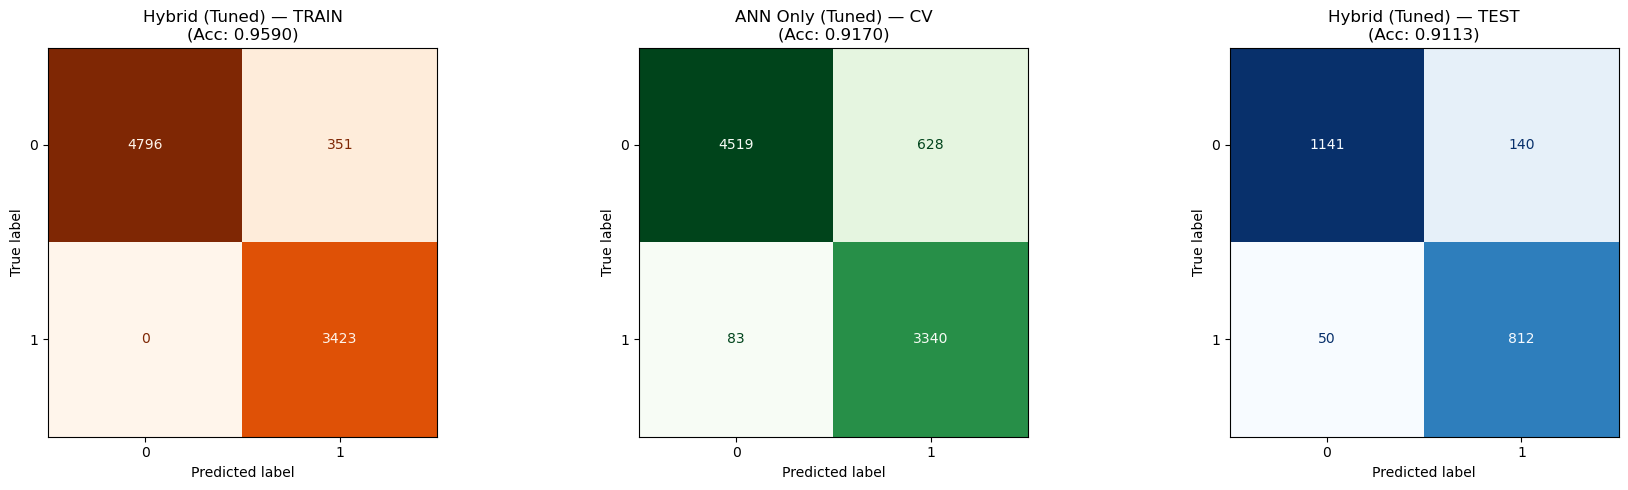

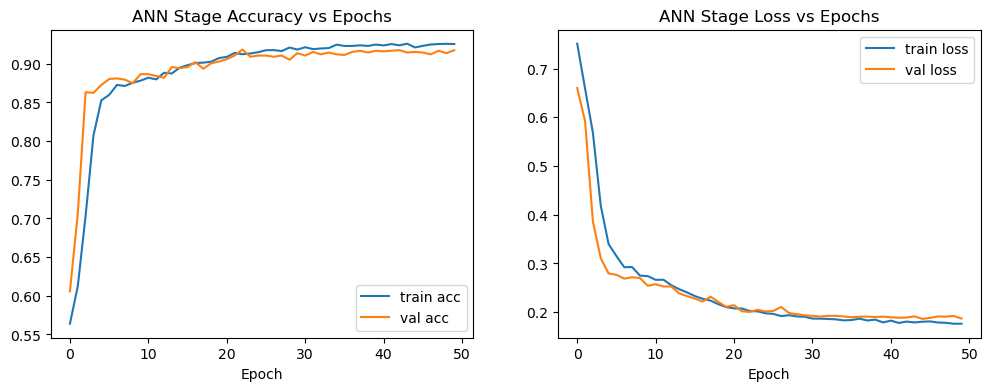


[HYBRID OCC] Generating Dynamics (Metrics vs Epochs)...
   ...Epoch 10/50
   ...Epoch 20/50
   ...Epoch 30/50
   ...Epoch 40/50
   ...Epoch 50/50


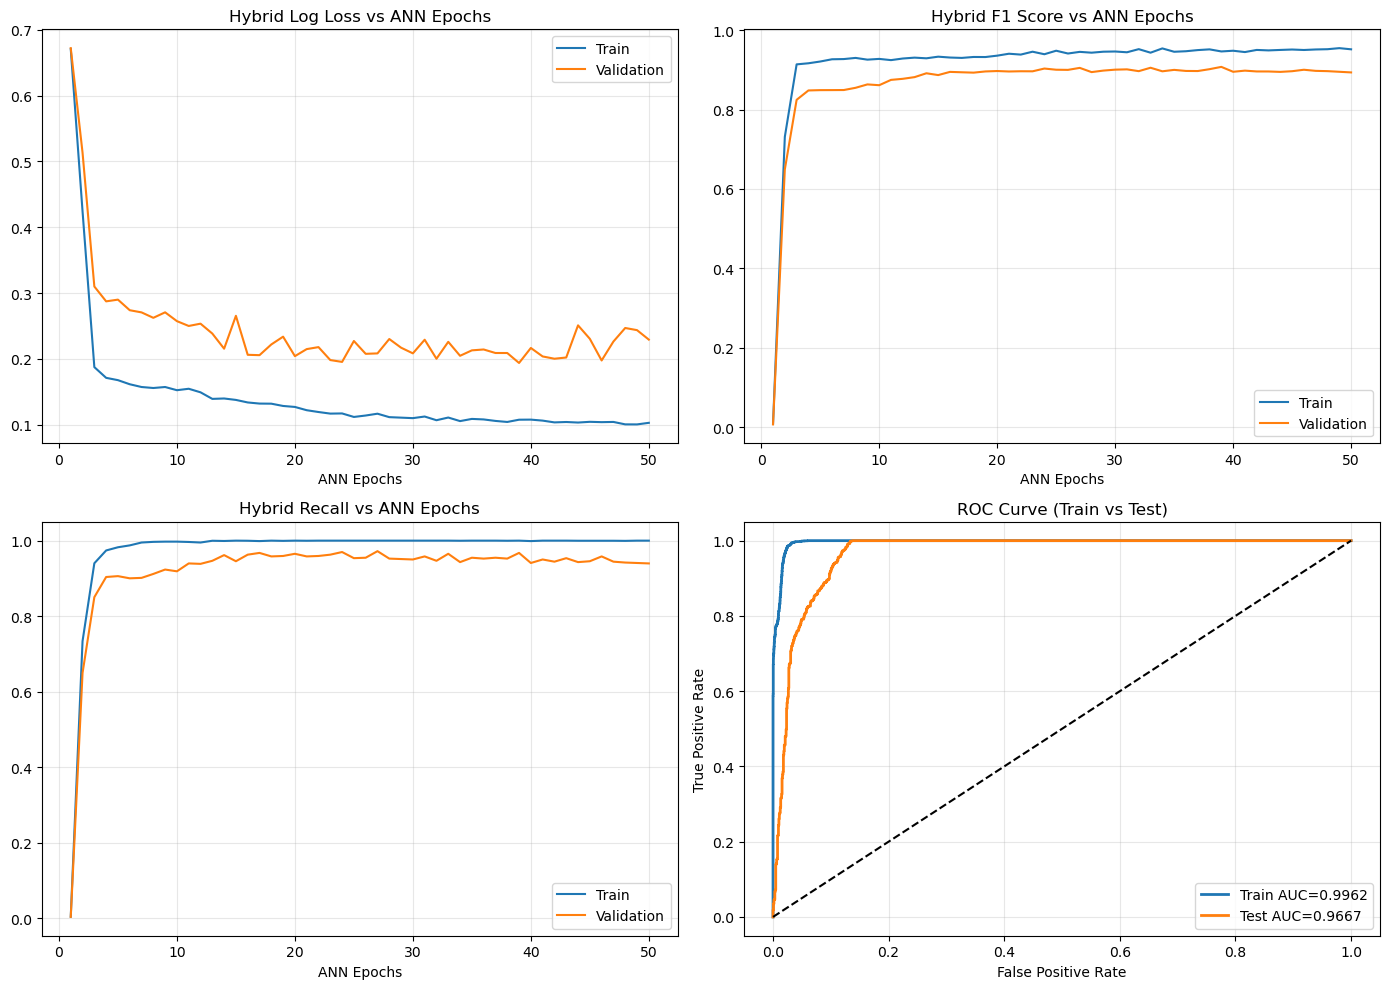

In [18]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers            # >>> NEW <<<
from tensorflow.keras.models import Model

# ============================================================
# 1. SETUP & PREPROCESSING
# ============================================================
def to_numpy(data):
    if hasattr(data, 'values'): return data.values
    return data

# Ensure Inputs are Float32
X_train_occ_ann = to_numpy(X_train_occ_enc).astype('float32')
X_test_occ_ann  = to_numpy(X_test_occ_enc).astype('float32')

# Ensure Targets are Numpy Arrays (Float32 for ANN)
y_train_occ = to_numpy(y_train_occ).astype('float32')
y_test_occ  = to_numpy(y_test_occ).astype('float32')

# Flatten for RF (1D Array)
y_train_occ_rf = y_train_occ.ravel()
y_test_occ_rf  = y_test_occ.ravel()

print(f"✅ OCCURRENCE VARIABLES READY (Tuned ANN + Base RF):")
print(f"   ANN Input: {X_train_occ_ann.shape}")
print(f"   RF Target: {y_train_occ_rf.shape}")

# ---------------- 2) Model Builders ----------------
def build_occ_feature_ann_tuned(input_dim: int) -> Model:
    """
    ANN Tuned: 128 -> 64 -> 48 -> 1
    Dropout 0.3, LR 0.001, L2 0.00001
    """
    inp = keras.Input(shape=(input_dim,), name="inp")
    
    # Layer 1
    x = layers.Dense(192, activation="relu", name="h1", kernel_regularizer=regularizers.l2(0.00001))(inp)
    x = layers.Dropout(0.3)(x)
    
    # Layer 2
    x = layers.Dense(45, activation="relu", name="h2", kernel_regularizer=regularizers.l2(0.00001))(x)
    x = layers.Dropout(0.3)(x)
    
    # Layer 3 (Feature Extractor - 16 units)
    h3 = layers.Dense(16, activation="relu", name="h3", kernel_regularizer=regularizers.l2(0.00001))(x) 
    
    # Output
    out = layers.Dense(1, activation="sigmoid", name="out")(h3)
    
    model = Model(inputs=inp, outputs=out, name="occ_ann_feat_tuned")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss="binary_crossentropy", metrics=["accuracy"])
    return model

def get_rf_baseline():
    """
    RF Baseline: 100 trees, Depth 10, Max Features None
    """
    return RandomForestClassifier(
        n_estimators=100, 
        max_depth=10, 
        max_features=None,
        min_samples_leaf=1, 
        min_samples_split=2,
        random_state=43, 
        n_jobs=-1
    )

# ---------------- 3) 10-Fold CV (ANN ONLY) ----------------
print("\n" + "="*60)
print("Starting 10-Fold CV on ANN Classifier Only...")
print("="*60)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'roc_auc': []}
y_pred_cv_ann = np.zeros(len(y_train_occ_rf), dtype=int) 
fold = 1

ann_train_time_cv = 0.0     # >>> NEW <<< accumulate ANN time over CV

for train_idx, val_idx in skf.split(X_train_occ_ann, y_train_occ_rf):
    # Split
    X_tr, X_val = X_train_occ_ann[train_idx], X_train_occ_ann[val_idx]
    y_tr, y_val = y_train_occ[train_idx], y_train_occ[val_idx]
    y_val_rf = y_train_occ_rf[val_idx] # For metrics
    
    # Train ANN (Tuned Params: Epochs 50, Batch 128)
    keras.backend.clear_session()
    ann_fold = build_occ_feature_ann_tuned(X_tr.shape[1])
    t0_ann_fold = time.time()                             # >>> NEW <<<
    ann_fold.fit(X_tr, y_tr, epochs=50, batch_size=128, verbose=0)
    ann_train_time_cv += time.time() - t0_ann_fold        # >>> NEW <<<
    
    # Evaluate ANN Directly
    proba_fold = ann_fold.predict(X_val, verbose=0).ravel()
    pred_fold = (proba_fold > 0.5).astype(int)
    
    y_pred_cv_ann[val_idx] = pred_fold
    
    # Metrics
    cv_metrics['accuracy'].append(accuracy_score(y_val_rf, pred_fold))
    cv_metrics['precision'].append(precision_score(y_val_rf, pred_fold, zero_division=0))
    cv_metrics['recall'].append(recall_score(y_val_rf, pred_fold, zero_division=0))
    cv_metrics['f1'].append(f1_score(y_val_rf, pred_fold, zero_division=0))
    cv_metrics['roc_auc'].append(roc_auc_score(y_val_rf, proba_fold))
    
    print(f"Fold {fold}/10 complete (ANN Only).")
    fold += 1

# ---------------- 3b) 10-Fold CV — HYBRID (ANN + RF) for Hypothesis 2 & 3 ----------------
print("\n" + "="*60)
print("Starting 10-Fold CV on HYBRID (ANN Feature Extractor + RF)...")
print("="*60)

hybrid_cv_rows = []           # overall per-fold metrics (for H2)
hybrid_strata_cv_rows = []    # per-fold per-stratum metrics (for H3)

fold_id = 1
strata = [0, 1]  # occurrence = 0 (no attack), 1 (attack)

for train_idx, val_idx in skf.split(X_train_occ_ann, y_train_occ_rf):
    # Split data for this fold
    X_tr, X_val = X_train_occ_ann[train_idx], X_train_occ_ann[val_idx]
    y_tr, y_val = y_train_occ[train_idx], y_train_occ[val_idx]       # float32 labels for ANN
    y_tr_rf = y_train_occ_rf[train_idx]                              # 1D int labels for RF
    y_val_rf = y_train_occ_rf[val_idx]

    # --- Train ANN for this fold ---
    keras.backend.clear_session()
    ann_fold = build_occ_feature_ann_tuned(X_tr.shape[1])
    ann_fold.fit(X_tr, y_tr, epochs=50, batch_size=128, verbose=0)

    # --- Extract features (h3 layer) ---
    ext_fold = Model(inputs=ann_fold.input, outputs=ann_fold.get_layer("h3").output)
    H3_tr = ext_fold.predict(X_tr, verbose=0)
    H3_val = ext_fold.predict(X_val, verbose=0)

    # --- Train RF on ANN features ---
    rf_fold = get_rf_baseline()
    rf_fold.fit(H3_tr, y_tr_rf)

    # --- Evaluate Hybrid on validation fold (overall) ---
    pred_val = rf_fold.predict(H3_val)
    proba_val = rf_fold.predict_proba(H3_val)[:, 1]

    acc_val  = accuracy_score(y_val_rf, pred_val)
    prec_val = precision_score(y_val_rf, pred_val, zero_division=0)
    rec_val  = recall_score(y_val_rf, pred_val, zero_division=0)
    f1_val   = f1_score(y_val_rf, pred_val, zero_division=0)
    auc_val  = roc_auc_score(y_val_rf, proba_val)

    hybrid_cv_rows.append({
        "model_name": "Hybrid_ANN_RF_occ",
        "fold_id": fold_id,
        "accuracy": acc_val,
        "precision": prec_val,
        "recall": rec_val,
        "f1": f1_val,
        "roc_auc": auc_val,
        "n_val_samples": int(len(y_val_rf)),
    })

    # --- Per-stratum metrics inside this fold (for H3) ---
    for s in strata:
        mask_s = (y_val_rf == s)
        y_true_s = y_val_rf[mask_s]
        if len(y_true_s) == 0:
            continue  # just in case, but stratified CV should give both classes

        H3_val_s = H3_val[mask_s]
        pred_val_s = pred_val[mask_s]
        proba_val_s = proba_val[mask_s]

        acc_s  = accuracy_score(y_true_s, pred_val_s)
        # Treat s as "positive" for this stratum-specific view
        prec_s = precision_score(y_true_s, pred_val_s, pos_label=s, zero_division=0)
        rec_s  = recall_score(y_true_s, pred_val_s, pos_label=s, zero_division=0)
        f1_s   = f1_score(y_true_s, pred_val_s, pos_label=s, zero_division=0)

        # AUC per stratum usually becomes undefined if only one class present;
        # but we keep the pattern and guard against the error.
        try:
            auc_s = roc_auc_score(y_true_s, proba_val_s)
        except ValueError:
            auc_s = np.nan

        meets_threshold = (f1_s >= 0.80) and (rec_s >= 0.80)  # adjust threshold if needed

        hybrid_strata_cv_rows.append({
            "model_name": "Hybrid_ANN_RF_occ",
            "fold_id": fold_id,
            "stratum_label": f"occurrence={s}",
            "n_val_samples_stratum": int(len(y_true_s)),
            "accuracy_stratum": acc_s,
            "precision_stratum": prec_s,
            "recall_stratum": rec_s,
            "f1_stratum": f1_s,
            "roc_auc_stratum": auc_s,
            "meets_threshold_stratum": meets_threshold,
        })

    print(f"Fold {fold_id}/10 complete (Hybrid ANN+RF). "
          f"Acc={acc_val:.4f}, F1={f1_val:.4f}, AUC={auc_val:.4f}")
    fold_id += 1

hybrid_occ_cv_results = pd.DataFrame(hybrid_cv_rows)
print("\n[H2] Hybrid ANN+RF — Per-Fold Metrics (10-Fold CV on Training Set):")
print(hybrid_occ_cv_results.to_string(index=False))

hybrid_occ_strata_cv_results = pd.DataFrame(hybrid_strata_cv_rows)
print("\n[H3] Hybrid ANN+RF — Per-Fold, Per-Stratum Metrics (10-Fold CV):")
print(hybrid_occ_strata_cv_results.to_string(index=False))

# For later statistical tests vs standalone models (in your other file):
hybrid_f1_folds   = hybrid_occ_cv_results["f1"].values
hybrid_acc_folds  = hybrid_occ_cv_results["accuracy"].values
hybrid_auc_folds  = hybrid_occ_cv_results["roc_auc"].values
hybrid_rec_folds  = hybrid_occ_cv_results["recall"].values
hybrid_prec_folds = hybrid_occ_cv_results["precision"].values

# ---------------- 4) Final Model Training (Hybrid) ----------------
print("\nTraining Final HYBRID Model (ANN+RF) on Full Training Set...")
# 1. Train ANN (Tuned)
t0_ann = time.time()
ann_final = build_occ_feature_ann_tuned(X_train_occ_ann.shape[1])
hist_final = ann_final.fit(
    X_train_occ_ann, y_train_occ, 
    validation_split=0.15, 
    epochs=50, batch_size=128, verbose=0
)
train_time_ann = time.time() - t0_ann

# 2. Extract Features
ext_final = Model(inputs=ann_final.input, outputs=ann_final.get_layer("h3").output)
H3_train_final = ext_final.predict(X_train_occ_ann, verbose=0)
H3_test_final = ext_final.predict(X_test_occ_ann, verbose=0)

# 3. Train RF (Baseline)
t0_rf = time.time()
rf_final = get_rf_baseline()
rf_final.fit(H3_train_final, y_train_occ_rf)
train_time_rf = time.time() - t0_rf
total_train_time = train_time_ann + train_time_rf

# Hybrid Train Metrics
pred_train = rf_final.predict(H3_train_final)
proba_train = rf_final.predict_proba(H3_train_final)[:, 1]
tr_acc = accuracy_score(y_train_occ_rf, pred_train)
tr_prec = precision_score(y_train_occ_rf, pred_train, zero_division=0)
tr_rec = recall_score(y_train_occ_rf, pred_train, zero_division=0)
tr_f1 = f1_score(y_train_occ_rf, pred_train, zero_division=0)
tr_auc = roc_auc_score(y_train_occ_rf, proba_train)

# ---------------- 5) Evaluate Test Set (Hybrid) ----------------
t0_test_rf = time.time()                        # >>> NEW <<<
pred_test = rf_final.predict(H3_test_final)
proba_test = rf_final.predict_proba(H3_test_final)[:, 1]
rf_testing_time = time.time() - t0_test_rf      # >>> NEW <<<

te_acc = accuracy_score(y_test_occ_rf, pred_test)
te_prec = precision_score(y_test_occ_rf, pred_test, zero_division=0)
te_rec = recall_score(y_test_occ_rf, pred_test, zero_division=0)
te_f1 = f1_score(y_test_occ_rf, pred_test, zero_division=0)
te_auc = roc_auc_score(y_test_occ_rf, proba_test)

# ---------------- 5b) Per-Stratum Test Metrics (for Hypothesis 3) ----------------
# Strata are defined on the true occurrence label: 0 = No attack, 1 = Yes attack

strata = [0, 1]
strata_rows = []

for s in strata:
    mask = (y_test_occ_rf == s)
    y_true_s = y_test_occ_rf[mask]
    y_pred_s = pred_test[mask]
    y_proba_s = proba_test[mask]

    if len(y_true_s) == 0:
        continue  # safety, in case some stratum is empty (shouldn't happen with stratified split)

    # Treat the stratum's class as the positive label so the metrics
    # are "how well do we recognize class s specifically?"
    acc_s  = accuracy_score(y_true_s, y_pred_s)
    prec_s = precision_score(y_true_s, y_pred_s, pos_label=s, zero_division=0)
    rec_s  = recall_score(y_true_s, y_pred_s, pos_label=s, zero_division=0)
    f1_s   = f1_score(y_true_s, y_pred_s, pos_label=s, zero_division=0)

    # For AUC per stratum: only meaningful if both 0 and 1 appear in y_true_s.
    # If the stratum is pure (all s), roc_auc_score will error, so we guard it.
    try:
        auc_s = roc_auc_score(y_true_s, y_proba_s)
    except ValueError:
        auc_s = np.nan

    # Define your "high performance" rule here (you can adjust the thresholds).
    meets_threshold = (f1_s >= 0.80) and (rec_s >= 0.80)

    strata_rows.append({
        "model_name": "Hybrid_ANN_RF_occ",
        "fold_id": "holdout_test",              # single split; if you add CV later, this can be 1..K
        "stratum_label": f"occurrence={s}",     # "occurrence=0" or "occurrence=1"
        "n_samples_stratum": int(len(y_true_s)),
        "accuracy_stratum": acc_s,
        "precision_stratum": prec_s,
        "recall_stratum": rec_s,
        "f1_stratum": f1_s,
        "roc_auc_stratum": auc_s,
        "meets_threshold_stratum": meets_threshold,
    })

occ_strata_results_hybrid = pd.DataFrame(strata_rows)
print("\n[H3] Per-Stratum Test Metrics for Hybrid ANN+RF (Occurrence):")
print(occ_strata_results_hybrid.to_string(index=False))


# ---------------- 6) Comparison Table ----------------
# Note: Middle Column is ANN ONLY (CV). Side columns are HYBRID.
print("\n" + "="*95)
print(f"{'[HYBRID OCC: Tuned ANN + Base RF]':<30} | {'TRAIN (Hybrid)':<18} | {'ANN ONLY (CV)':<20} | {'TEST (Hybrid)':<18}")
print("-" * 95)
print(f"{'Accuracy':<30} | {tr_acc:<18.4f} | {np.mean(cv_metrics['accuracy']):<20.4f} | {te_acc:<18.4f}")
print(f"{'Precision':<30} | {tr_prec:<18.4f} | {np.mean(cv_metrics['precision']):<20.4f} | {te_prec:<18.4f}")
print(f"{'Recall':<30} | {tr_rec:<18.4f} | {np.mean(cv_metrics['recall']):<20.4f} | {te_rec:<18.4f}")
print(f"{'F1 Score':<30} | {tr_f1:<18.4f} | {np.mean(cv_metrics['f1']):<20.4f} | {te_f1:<18.4f}")
print(f"{'ROC AUC':<30} | {tr_auc:<18.4f} | {np.mean(cv_metrics['roc_auc']):<20.4f} | {te_auc:<18.4f}")
print("=" * 95)
# >>> NEW <<< timing summary in the same style as your example
ann_feature_extractor_train_time = ann_train_time_cv + train_time_ann
rf_classifier_train_time = train_time_rf
total_train_time = ann_feature_extractor_train_time + rf_classifier_train_time

print(f"ANN Feature Extractor Train Time: {ann_feature_extractor_train_time:.2f}s")
print(f"RF Classifier Train Time: {rf_classifier_train_time:.2f}s")
print(f"Total Training Time (ANN + RF): {total_train_time:.2f}s")
print(f"RF Testing Time: {rf_testing_time:.2f}s")

# ---------------- 7) Visualizations ----------------

## A. Confusion Matrices
fig_cm, axes_cm = plt.subplots(1, 3, figsize=(18, 5))

# 1. Hybrid Train
cm_train = confusion_matrix(y_train_occ_rf, pred_train, labels=[0, 1])
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=[0, 1])
disp_train.plot(ax=axes_cm[0], values_format='d', colorbar=False, cmap='Oranges')
axes_cm[0].set_title(f"Hybrid (Tuned) — TRAIN\n(Acc: {tr_acc:.4f})")

# 2. ANN Only (CV)
cm_cv = confusion_matrix(y_train_occ_rf, y_pred_cv_ann, labels=[0, 1])
disp_cv = ConfusionMatrixDisplay(confusion_matrix=cm_cv, display_labels=[0, 1])
disp_cv.plot(ax=axes_cm[1], values_format='d', colorbar=False, cmap='Greens')
axes_cm[1].set_title(f"ANN Only (Tuned) — CV\n(Acc: {np.mean(cv_metrics['accuracy']):.4f})")

# 3. Hybrid Test
cm_test = confusion_matrix(y_test_occ_rf, pred_test, labels=[0, 1])
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=[0, 1])
disp_test.plot(ax=axes_cm[2], values_format='d', colorbar=False, cmap='Blues')
axes_cm[2].set_title(f"Hybrid (Tuned) — TEST\n(Acc: {te_acc:.4f})")

plt.tight_layout()
plt.show()

## B. ANN Training Curves
fig_ep, axes_ep = plt.subplots(1, 2, figsize=(12, 4))
axes_ep[0].plot(hist_final.history["accuracy"], '-', label="train acc")
try: axes_ep[0].plot(hist_final.history["val_accuracy"], '-', label="val acc")
except: pass
axes_ep[0].set_title("ANN Stage Accuracy vs Epochs")
axes_ep[0].legend()
axes_ep[0].set_xlabel("Epoch")

axes_ep[1].plot(hist_final.history["loss"], '-', label="train loss")
try: axes_ep[1].plot(hist_final.history["val_loss"], '-', label="val loss")
except: pass
axes_ep[1].set_title("ANN Stage Loss vs Epochs")
axes_ep[1].legend()
axes_ep[1].set_xlabel("Epoch")
plt.show()

## C. Dynamics (Metrics vs Epochs) - Hybrid Dynamics
print("\n[HYBRID OCC] Generating Dynamics (Metrics vs Epochs)...")
keras.backend.clear_session()
ann_dyn = build_occ_feature_ann_tuned(X_train_occ_ann.shape[1])
epochs_range = range(1, 51) # 50 Epochs
d_loss_tr, d_loss_te = [], []
d_f1_tr, d_f1_te = [], []
d_rec_tr, d_rec_te = [], [] 

for epoch in epochs_range:
    ann_dyn.fit(X_train_occ_ann, y_train_occ, epochs=1, batch_size=128, verbose=0)
    
    # Extract & Train RF
    ext_dyn = Model(inputs=ann_dyn.input, outputs=ann_dyn.get_layer("h3").output)
    h3_tr = ext_dyn.predict(X_train_occ_ann, verbose=0)
    h3_te = ext_dyn.predict(X_test_occ_ann, verbose=0)
    
    rf_dyn = get_rf_baseline()
    rf_dyn.fit(h3_tr, y_train_occ_rf)
    
    p_tr, p_te = rf_dyn.predict(h3_tr), rf_dyn.predict(h3_te)
    prob_tr, prob_te = rf_dyn.predict_proba(h3_tr)[:, 1], rf_dyn.predict_proba(h3_te)[:, 1]
    
    d_loss_tr.append(log_loss(y_train_occ_rf, prob_tr))
    d_loss_te.append(log_loss(y_test_occ_rf, prob_te))
    d_f1_tr.append(f1_score(y_train_occ_rf, p_tr, zero_division=0))
    d_f1_te.append(f1_score(y_test_occ_rf, p_te, zero_division=0))
    d_rec_tr.append(recall_score(y_train_occ_rf, p_tr, zero_division=0)) 
    d_rec_te.append(recall_score(y_test_occ_rf, p_te, zero_division=0)) 
    
    if epoch % 10 == 0: print(f"   ...Epoch {epoch}/50")

# Plotting Dynamics (Clean Lines)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Log Loss
axes[0, 0].plot(epochs_range, d_loss_tr, '-', label='Train', color='tab:blue')
axes[0, 0].plot(epochs_range, d_loss_te, '-', label='Validation', color='tab:orange')
axes[0, 0].set_title("Hybrid Log Loss vs ANN Epochs")
axes[0, 0].set_xlabel("ANN Epochs")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. F1 Score
axes[0, 1].plot(epochs_range, d_f1_tr, '-', label='Train', color='tab:blue')
axes[0, 1].plot(epochs_range, d_f1_te, '-', label='Validation', color='tab:orange')
axes[0, 1].set_title("Hybrid F1 Score vs ANN Epochs")
axes[0, 1].set_xlabel("ANN Epochs")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Recall
axes[1, 0].plot(epochs_range, d_rec_tr, '-', label='Train', color='tab:blue')
axes[1, 0].plot(epochs_range, d_rec_te, '-', label='Validation', color='tab:orange')
axes[1, 0].set_title("Hybrid Recall vs ANN Epochs")
axes[1, 0].set_xlabel("ANN Epochs")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. ROC Curve (Train vs Test)
fpr_tr, tpr_tr, _ = roc_curve(y_train_occ_rf, proba_train)
fpr_te, tpr_te, _ = roc_curve(y_test_occ_rf, proba_test)

axes[1, 1].plot(fpr_tr, tpr_tr, '-', label=f'Train AUC={tr_auc:.4f}', color='tab:blue', linewidth=2)
axes[1, 1].plot(fpr_te, tpr_te, '-', label=f'Test AUC={te_auc:.4f}', color='tab:orange', linewidth=2)
axes[1, 1].plot([0, 1], [0, 1], 'k--')
axes[1, 1].set_title("ROC Curve (Train vs Test)")
axes[1, 1].set_xlabel("False Positive Rate")
axes[1, 1].set_ylabel("True Positive Rate")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
import joblib
import os

# Define path
save_path = '../saved_models'
if not os.path.exists(save_path):
    os.makedirs(save_path)

print("SAVING HYBRID DETECTION RESOURCES...")

# 1. Save Feature Extractor (Keras Model)
# At this point, 'ext_final' is the Occurrence Feature Extractor
ext_final.save(os.path.join(save_path, 'hybrid_detection_extractor.keras'))
print(" - Extractor saved: hybrid_detection_extractor.keras")

# 2. Save RF Classifier
# At this point, 'rf_final' is the Occurrence Classifier
joblib.dump(rf_final, os.path.join(save_path, 'hybrid_detection_rf.pkl'))
print(" - RF Classifier saved: hybrid_detection_rf.pkl")

# 3. Save Preprocessor
# In your hybrid notebook, the preprocessor is 'pre_occ'
joblib.dump(pre_occ, os.path.join(save_path, 'hybrid_detection_preprocessor.pkl'))
print(" - Preprocessor saved: hybrid_detection_preprocessor.pkl")

print("✅ Hybrid Detection resources secured.")

SAVING HYBRID DETECTION RESOURCES...
 - Extractor saved: hybrid_detection_extractor.keras
 - RF Classifier saved: hybrid_detection_rf.pkl
 - Preprocessor saved: hybrid_detection_preprocessor.pkl
✅ Hybrid Detection resources secured.


In [20]:
# make_folds_occurrence.py (or at top of your hybrid script)
import numpy as np
from sklearn.model_selection import StratifiedKFold

# X_occ and y_occ must be in the exact same order that ALL scripts use
X_occ = X_train_occ_ann          # or your base encoded X
y_occ = y_train_occ_rf           # shape (N,)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

folds = []
for train_idx, val_idx in skf.split(X_occ, y_occ):
    folds.append({"train": train_idx, "val": val_idx})

np.save("occurrence_cv_folds.npy", folds, allow_pickle=True)
print("Saved occurrence folds to occurrence_cv_folds.npy")

Saved occurrence folds to occurrence_cv_folds.npy


### ------***Artificial Neural Network - Random Forest (ANN-RF) - Severity Model***------

In [21]:
# ============================================================
# Unified ANN Severity Model (Predicts 1, 2, 3) - Setup
# ============================================================

# --- 1. Prepare Full Training Data ---
# We use the FULL train_df (Diagnosis 0 AND 1).
EXCLUDE_SEV = {
    PAS_LABEL_COL,                  # Target
    DIAGNOSIS_COL,                  # Occurrence Target
    'Severity_Category',            # Direct leak
    'Composite_Severity_Index',     # Direct leak
    # 'Severity', 
    # 'Impact on Life',
    "Symptoms",
    PAO_LABEL_COL, PAO_PROBA_COL,   # Placeholders
    PAS_PROBA_COL                   # Placeholder
}

#ORIGINALLY FOR OCCURRENCE
# EXCLUDE_SEV = {
#     'Panic Disorder Diagnosis',     # occurrence target
    
#     # Placeholder/Output Columns (not features)
#     PAO_LABEL_COL, PAO_PROBA_COL,   
#     PAS_LABEL_COL, PAS_PROBA_COL,   
    
#     # Leaky/Redundant Features (from your original list)
#     # 'Severity',
#     # 'Impact on Life',
#     # 'Severity_num',
#     # 'Impact on Life_num',
#     # 'Symptoms',
    
#     # --- ADDED AS REQUESTED ---
#     'Composite_Severity_Index',
#     'Severity_Category'
# }

FEATURE_COLS = [c for c in train_df.columns if c not in EXCLUDE_SEV]

X_train_all = train_df[FEATURE_COLS].copy()
y_train_all = train_df[PAS_LABEL_COL].astype(int) # Classes: 1, 2, 3

X_test_all  = test_df.reindex(columns=FEATURE_COLS).copy()
y_test_all  = test_df[PAS_LABEL_COL].astype(int)

# --- 2. Encode Features (StandardScaler is better for ANN) ---
num_cols = X_train_all.select_dtypes(include=['number']).columns.tolist()
cat_cols = X_train_all.select_dtypes(include=['object']).columns.tolist()

# Use StandardScaler for numeric cols to help ANN convergence
preprocessor_ann = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
])

X_train_all_enc = preprocessor_ann.fit_transform(X_train_all)
X_test_all_enc  = preprocessor_ann.transform(X_test_all)

# --- 3. Apply SMOTE (Balance 1, 2, and 3) ---
print("\n[ANN SEV] Applying SMOTE to balance classes {1, 2, 3}...")
print(f"Original Counts: {dict(zip(*np.unique(y_train_all, return_counts=True)))}")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_all_enc, y_train_all)

print(f"SMOTE Counts:    {dict(zip(*np.unique(y_train_smote, return_counts=True)))}")

# --- 4. Prepare Data for Keras/TensorFlow ---

# A. Transform Target Labels to One-Hot Encoding 
# First Map {1, 2, 3} -> {0, 1, 2}
le = LabelEncoder()
y_train_le = le.fit_transform(y_train_smote)
y_test_le  = le.transform(y_test_all)

# Then Convert to binary class matrix (One-Hot) for 'categorical_crossentropy'
y_train_ann_sev = to_categorical(y_train_le, num_classes=3)
y_test_ann_sev  = to_categorical(y_test_le, num_classes=3)

# B. Ensure Features are Float32
X_train_ann_sev = X_train_smote.astype('float32')
X_test_ann_sev  = X_test_all_enc.astype('float32')

print("\nHybrid SEV] Data Preparation Complete")
print(f"X_train shape: {X_train_ann_sev.shape} (Float32)")
print(f"y_train shape: {y_train_ann_sev.shape} (One-Hot)")
print(f"Class mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")


[ANN SEV] Applying SMOTE to balance classes {1, 2, 3}...
Original Counts: {1: 3245, 2: 2700, 3: 2625}
SMOTE Counts:    {1: 3245, 2: 3245, 3: 3245}

Hybrid SEV] Data Preparation Complete
X_train shape: (9735, 39) (Float32)
y_train shape: (9735, 3) (One-Hot)
Class mapping: {1: 0, 2: 1, 3: 2}


In [22]:
# make_folds_severity.py
import numpy as np
from sklearn.model_selection import StratifiedKFold

X_sev = X_train_ann_sev          # same order in all scripts
y_sev = y_train_smote            # integer 1/2/3 BEFORE SMOTE if you keep that version

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

folds = []
for train_idx, val_idx in skf.split(X_sev, y_sev):
    folds.append({"train": train_idx, "val": val_idx})

np.save("severity_cv_folds.npy", folds, allow_pickle=True)
print("Saved severity folds to severity_cv_folds.npy")

Saved severity folds to severity_cv_folds.npy


# HYBRID SEVERITY 1: ANN (Tuned Best Params) -> RF (Baseline)

✅ VARIABLES READY (CV on ANN Only):
   ANN Input: (9735, 39)
   ANN Target (One-Hot): (9735, 3)
   RF Target (Int): (9735,)

Starting 10-Fold CV on ANN Classifier Only...
Fold 1/10 complete (ANN Only).
Fold 2/10 complete (ANN Only).
Fold 3/10 complete (ANN Only).
Fold 4/10 complete (ANN Only).
Fold 5/10 complete (ANN Only).
Fold 6/10 complete (ANN Only).
Fold 7/10 complete (ANN Only).
Fold 8/10 complete (ANN Only).
Fold 9/10 complete (ANN Only).
Fold 10/10 complete (ANN Only).

Starting 10-Fold CV on HYBRID (ANN Feature Extractor + RF) [SEVERITY]...
Fold 1/10 complete (Hybrid SEV ANN+RF). Acc_w=0.9559, F1_w=0.9560, AUC_w=0.9858
Fold 2/10 complete (Hybrid SEV ANN+RF). Acc_w=0.9610, F1_w=0.9611, AUC_w=0.9888
Fold 3/10 complete (Hybrid SEV ANN+RF). Acc_w=0.9600, F1_w=0.9600, AUC_w=0.9832
Fold 4/10 complete (Hybrid SEV ANN+RF). Acc_w=0.9671, F1_w=0.9672, AUC_w=0.9866
Fold 5/10 complete (Hybrid SEV ANN+RF). Acc_w=0.9630, F1_w=0.9630, AUC_w=0.9884
Fold 6/10 complete (Hybrid SEV ANN+RF). Acc_

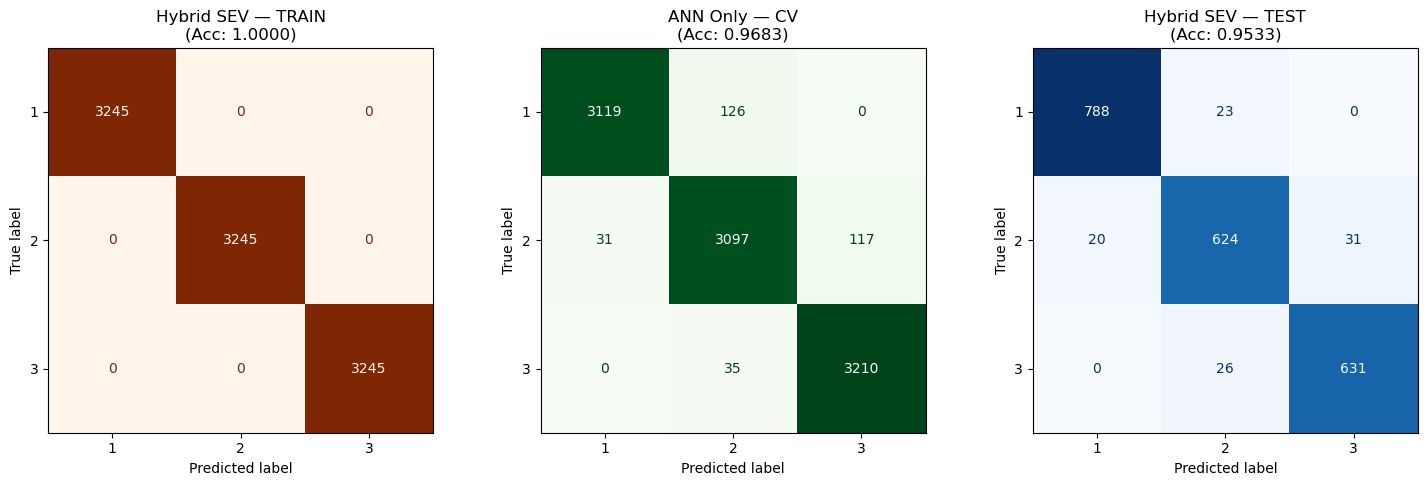

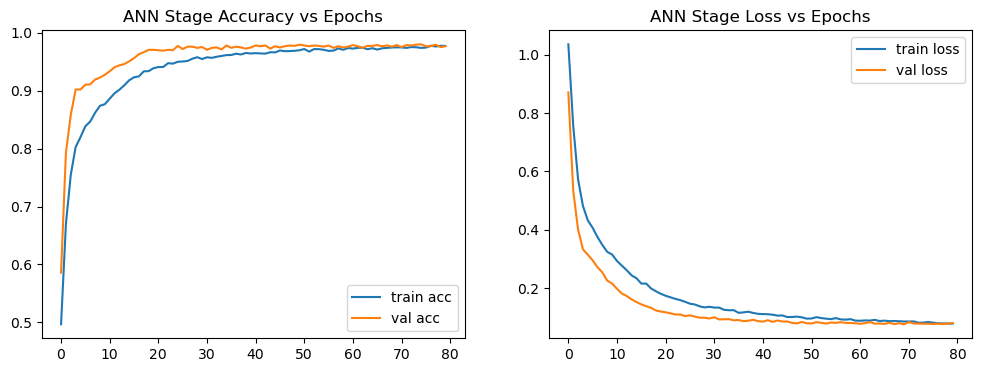


[HYBRID SEV] Generating Dynamics (Metrics vs Epochs)...
   ...Epoch 10/80
   ...Epoch 20/80
   ...Epoch 30/80
   ...Epoch 40/80
   ...Epoch 50/80
   ...Epoch 60/80
   ...Epoch 70/80
   ...Epoch 80/80


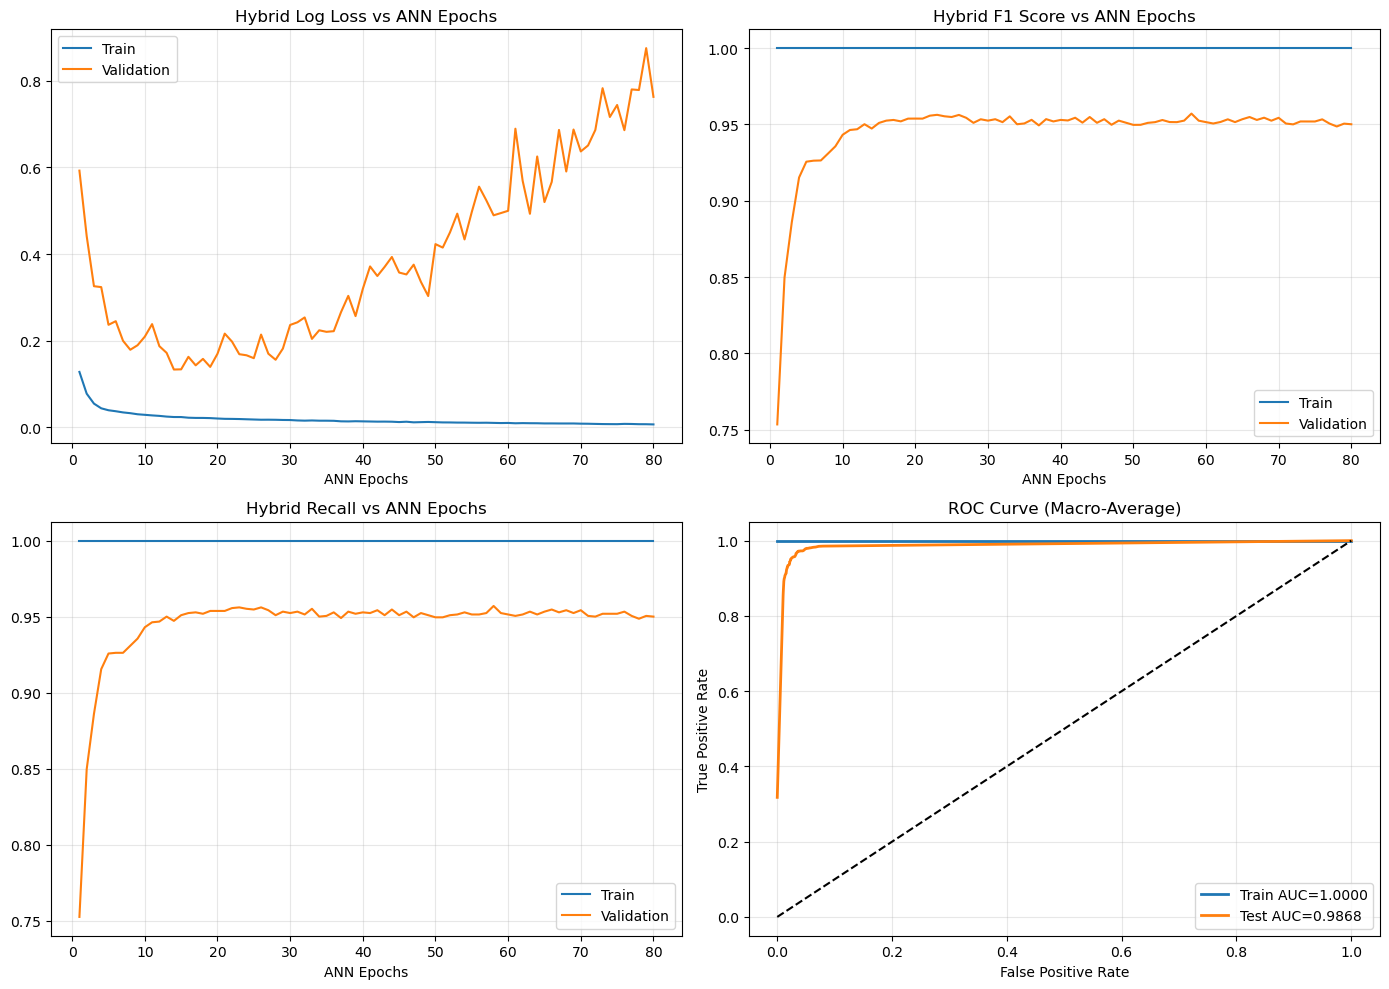

In [23]:
# ============================================================
# HYBRID SEVERITY: ANN (Tuned Extractor) -> RF (Baseline)
# ============================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import label_binarize
from sklearn.preprocessing import label_binarize, LabelEncoder   # >>> NEW <<<

# ============================================================
# 1. SETUP & PREPROCESSING
# ============================================================
# Helper to ensure proper array format
def to_numpy(data):
    if hasattr(data, 'values'):
        return data.values
    return data

# Ensure y_test_sev exists
try:
    y_test_sev = to_numpy(y_test_all)
except NameError:
    y_test_sev = test_df["Panic Attack Severity"].astype(int).values

# Ensure Inputs are Float32
X_train_ann_sev = to_numpy(X_train_ann_sev).astype('float32')
X_test_ann_sev  = to_numpy(X_test_ann_sev).astype('float32')

# Ensure RF Targets are 1D Arrays (Integers)
y_train_smote = to_numpy(y_train_smote)
if len(y_train_smote.shape) > 1:
    y_train_smote = y_train_smote.ravel()

# Ensure ANN Targets are One-Hot (for Categorical Crossentropy)
# Note: y_train_ann_sev should already be one-hot from previous steps.
# If not, we recreate it from y_train_smote (classes 1,2,3 -> index 0,1,2)
if len(y_train_ann_sev.shape) == 1 or y_train_ann_sev.shape[1] != 3:
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    y_int = le.fit_transform(y_train_smote) # 1,2,3 -> 0,1,2
    y_train_ann_sev = to_categorical(y_int, num_classes=3)

print(f"✅ VARIABLES READY (CV on ANN Only):")
print(f"   ANN Input: {X_train_ann_sev.shape}")
print(f"   ANN Target (One-Hot): {y_train_ann_sev.shape}")
print(f"   RF Target (Int): {y_train_smote.shape}")

# ---------------- 2) Model Builders ----------------
def build_sev_ann_tuned(input_dim: int) -> Model:
    """
    ANN Tuned: 90 -> 64 -> 20 (Features) -> 3 (Softmax)
    Dropout: 0.2, L2: 0.0001, LR: 0.0005
    """
    inp = keras.Input(shape=(input_dim,), name="inp")
    
    # Layer 1
    x = layers.Dense(90, activation="relu", kernel_regularizer=regularizers.l2(0.0001))(inp)
    x = layers.Dropout(0.3)(x)
    
    # Layer 2
    x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.0001))(x)
    x = layers.Dropout(0.3)(x)
    
    # Layer 3 (Feature Extractor)
    h3 = layers.Dense(20, activation="relu", kernel_regularizer=regularizers.l2(0.0001), name="h3")(x)
    
    # Output
    out = layers.Dense(3, activation="softmax", name="out")(h3)
    
    model = Model(inputs=inp, outputs=out, name="sev_ann_tuned")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005), 
                  loss="categorical_crossentropy", metrics=["accuracy"])
    return model

def get_rf_baseline():
    return RandomForestClassifier(n_estimators=100, max_depth=None, 
                                  min_samples_leaf=1, min_samples_split=2, 
                                  max_features=None, random_state=43, n_jobs=-1)

# ---------------- 3) 10-Fold CV (ANN ONLY) ----------------
print("\n" + "="*60)
print("Starting 10-Fold CV on ANN Classifier Only...")
print("="*60)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'roc_auc': []}
y_pred_cv_ann = np.zeros(len(y_train_smote), dtype=int) # Store ANN predictions
fold = 1

ann_train_time_cv = 0.0   # >>> NEW <<< accumulate ANN CV time

for train_idx, val_idx in skf.split(X_train_ann_sev, y_train_smote):
    X_tr, X_val = X_train_ann_sev[train_idx], X_train_ann_sev[val_idx]
    y_tr_oh, y_val_oh = y_train_ann_sev[train_idx], y_train_ann_sev[val_idx]
    y_val_int = y_train_smote[val_idx]
    
    # Train ANN
    keras.backend.clear_session()
    ann_fold = build_sev_ann_tuned(X_tr.shape[1])
    t0_ann_fold = time.time()                                  # >>> NEW <<<
    ann_fold.fit(X_tr, y_tr_oh, epochs=80, batch_size=128, verbose=0)
    ann_train_time_cv += time.time() - t0_ann_fold
    
    # Evaluate ANN Directly
    proba_fold = ann_fold.predict(X_val, verbose=0)
    pred_fold_indices = np.argmax(proba_fold, axis=1)
    # Map indices 0,1,2 back to 1,2,3 if needed, but checking direct mapping
    # Assuming y_train_smote is 1,2,3. We need to ensure pred_fold matches.
    # If labels are 1,2,3, argmax 0->1, 1->2, 2->3
    pred_fold = pred_fold_indices + 1 
    
    y_pred_cv_ann[val_idx] = pred_fold
    
    # Metrics
    cv_metrics['accuracy'].append(accuracy_score(y_val_int, pred_fold))
    cv_metrics['precision'].append(precision_score(y_val_int, pred_fold, average='weighted', zero_division=0))
    cv_metrics['recall'].append(recall_score(y_val_int, pred_fold, average='weighted', zero_division=0))
    cv_metrics['f1'].append(f1_score(y_val_int, pred_fold, average='weighted', zero_division=0))
    try: cv_metrics['roc_auc'].append(roc_auc_score(y_val_int, proba_fold, multi_class='ovr', average='weighted'))
    except: pass
    
    print(f"Fold {fold}/10 complete (ANN Only).")
    fold += 1
# ---------------- 3b) 10-Fold CV — HYBRID (ANN + RF) for Severity (H2 & H3) ----------------
print("\n" + "="*60)
print("Starting 10-Fold CV on HYBRID (ANN Feature Extractor + RF) [SEVERITY]...")
print("="*60)

sev_hybrid_cv_rows = []           # overall per-fold metrics (for H2)
sev_hybrid_strata_cv_rows = []    # per-fold, per-severity metrics (for H3)

classes = [1, 2, 3]  # severity levels: 1 = Mild, 2 = Moderate, 3 = Severe
fold_id = 1

for train_idx, val_idx in skf.split(X_train_ann_sev, y_train_smote):
    # Split data for this fold
    X_tr, X_val = X_train_ann_sev[train_idx], X_train_ann_sev[val_idx]
    y_tr_oh, y_val_oh = y_train_ann_sev[train_idx], y_train_ann_sev[val_idx]  # one-hot for ANN
    y_tr_int, y_val_int = y_train_smote[train_idx], y_train_smote[val_idx]    # int labels (1,2,3) for RF

    # --- Train ANN for this fold ---
    keras.backend.clear_session()
    ann_fold = build_sev_ann_tuned(X_tr.shape[1])
    ann_fold.fit(X_tr, y_tr_oh, epochs=80, batch_size=128, verbose=0)

    # --- Extract features from h3 layer ---
    ext_fold = Model(inputs=ann_fold.input, outputs=ann_fold.get_layer("h3").output)
    H3_tr = ext_fold.predict(X_tr, verbose=0)
    H3_val = ext_fold.predict(X_val, verbose=0)

    # --- Train RF on ANN features ---
    rf_fold = get_rf_baseline()
    rf_fold.fit(H3_tr, y_tr_int)

    # --- Evaluate Hybrid on validation fold (overall metrics) ---
    pred_val  = rf_fold.predict(H3_val)
    proba_val = rf_fold.predict_proba(H3_val)  # shape (N_val, 3)

    acc_val  = accuracy_score(y_val_int, pred_val)
    prec_val = precision_score(y_val_int, pred_val, average='weighted', zero_division=0)
    rec_val  = recall_score(y_val_int, pred_val, average='weighted', zero_division=0)
    f1_val   = f1_score(y_val_int, pred_val, average='weighted', zero_division=0)
    auc_val  = roc_auc_score(y_val_int, proba_val, multi_class='ovr', average='weighted')

    sev_hybrid_cv_rows.append({
        "model_name": "Hybrid_ANN_RF_sev",
        "fold_id": fold_id,
        "accuracy_weighted": acc_val,
        "precision_weighted": prec_val,
        "recall_weighted": rec_val,
        "f1_weighted": f1_val,
        "roc_auc_weighted": auc_val,
        "n_val_samples": int(len(y_val_int)),
    })

    # --- Per-severity (per-stratum) metrics inside this fold (for H3) ---
    # Use confusion matrix to get per-class precision/recall/F1
    cm = confusion_matrix(y_val_int, pred_val, labels=classes)  # rows = true, cols = pred

    for i, c in enumerate(classes):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        support_c = cm[i, :].sum()  # number of true samples with class c

        if support_c == 0:
            continue  # no samples of this class in this fold

        # Per-class metrics
        prec_c = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        rec_c  = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        f1_c   = (2 * prec_c * rec_c / (prec_c + rec_c)) if (prec_c + rec_c) > 0 else 0.0

        # One-vs-rest ROC AUC for this class
        y_true_bin = (y_val_int == c).astype(int)
        try:
            auc_c = roc_auc_score(y_true_bin, proba_val[:, i])
        except ValueError:
            auc_c = np.nan  # if only one class present in y_true_bin

        # Define your "high performance" rule per severity level
        meets_threshold = (f1_c >= 0.80) and (rec_c >= 0.80)  # adjust if needed

        sev_hybrid_strata_cv_rows.append({
            "model_name": "Hybrid_ANN_RF_sev",
            "fold_id": fold_id,
            "stratum_label": f"severity={c}",   # 1, 2, 3
            "n_val_samples_stratum": int(support_c),
            "precision_stratum": prec_c,
            "recall_stratum": rec_c,
            "f1_stratum": f1_c,
            "roc_auc_stratum": auc_c,
            "meets_threshold_stratum": meets_threshold,
        })

    print(f"Fold {fold_id}/10 complete (Hybrid SEV ANN+RF). "
          f"Acc_w={acc_val:.4f}, F1_w={f1_val:.4f}, AUC_w={auc_val:.4f}")
    fold_id += 1

sev_hybrid_cv_results = pd.DataFrame(sev_hybrid_cv_rows)
print("\n[H2] Hybrid SEV — Per-Fold Metrics (10-Fold CV on Training Set):")
print(sev_hybrid_cv_results.to_string(index=False))

sev_hybrid_strata_cv_results = pd.DataFrame(sev_hybrid_strata_cv_rows)
print("\n[H3] Hybrid SEV — Per-Fold, Per-Severity Metrics (10-Fold CV):")
print(sev_hybrid_strata_cv_results.to_string(index=False))

# For later statistical tests vs standalone models (in your other file):
sev_hybrid_f1_folds   = sev_hybrid_cv_results["f1_weighted"].values
sev_hybrid_acc_folds  = sev_hybrid_cv_results["accuracy_weighted"].values
sev_hybrid_auc_folds  = sev_hybrid_cv_results["roc_auc_weighted"].values
sev_hybrid_rec_folds  = sev_hybrid_cv_results["recall_weighted"].values
sev_hybrid_prec_folds = sev_hybrid_cv_results["precision_weighted"].values


# ---------------- 4) Final Model Training (HYBRID) ----------------
print("\nTraining Final HYBRID Model (ANN+RF) on Full Training Set...")
t0_ann = time.time()

# 1. Train ANN (Tuned)
t0_ann = time.time()                                         # >>> NEW <<<

ann_final = build_sev_ann_tuned(X_train_ann_sev.shape[1])
hist_final = ann_final.fit(X_train_ann_sev, y_train_ann_sev, validation_split=0.15, 
                           epochs=80, batch_size=128, verbose=0)
train_time_ann = time.time() - t0_ann                        # >>> NEW <<<


# 2. Extract Features
ext_final = Model(inputs=ann_final.input, outputs=ann_final.get_layer("h3").output)
H3_train_final = ext_final.predict(X_train_ann_sev, verbose=0)
H3_test_final  = ext_final.predict(X_test_ann_sev, verbose=0)

# 3. Train RF (Baseline)
t0_rf = time.time()                                          # >>> NEW <<<
rf_final = get_rf_baseline()
rf_final.fit(H3_train_final, y_train_smote)
train_time_rf = time.time() - t0_rf                          # >>> NEW <<<

# Hybrid Train Metrics
pred_train = rf_final.predict(H3_train_final)
proba_train = rf_final.predict_proba(H3_train_final)
tr_acc = accuracy_score(y_train_smote, pred_train)
tr_prec = precision_score(y_train_smote, pred_train, average='weighted', zero_division=0)
tr_rec = recall_score(y_train_smote, pred_train, average='weighted', zero_division=0)
tr_f1 = f1_score(y_train_smote, pred_train, average='weighted', zero_division=0)
tr_auc = roc_auc_score(y_train_smote, proba_train, multi_class='ovr', average='weighted')

# ---------------- 5) Evaluate Test Set (HYBRID) ----------------
t0_test_rf = time.time()                                     # >>> NEW <<<
pred_test = rf_final.predict(H3_test_final)
proba_test = rf_final.predict_proba(H3_test_final)
rf_testing_time = time.time() - t0_test_rf                   # >>> NEW <<<

te_acc = accuracy_score(y_test_sev, pred_test)
te_prec = precision_score(y_test_sev, pred_test, average='weighted', zero_division=0)
te_rec = recall_score(y_test_sev, pred_test, average='weighted', zero_division=0)
te_f1 = f1_score(y_test_sev, pred_test, average='weighted', zero_division=0)
te_auc = roc_auc_score(y_test_sev, proba_test, multi_class='ovr', average='weighted')

# ---------------- 5b) Per-Stratum Test Metrics (for Hypothesis 3 — Severity) ----------------
classes = [1, 2, 3]  # severity = 1,2,3
sev_strata_test_rows = []

cm_test = confusion_matrix(y_test_sev, pred_test, labels=classes)  # rows = true, cols = pred

for i, c in enumerate(classes):
    TP = cm_test[i, i]
    FN = cm_test[i, :].sum() - TP
    FP = cm_test[:, i].sum() - TP
    support_c = cm_test[i, :].sum()  # number of true samples of severity c

    if support_c == 0:
        continue

    prec_c = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    rec_c  = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1_c   = (2 * prec_c * rec_c / (prec_c + rec_c)) if (prec_c + rec_c) > 0 else 0.0

    # One-vs-rest AUC for this severity level
    y_true_bin = (y_test_sev == c).astype(int)
    try:
        auc_c = roc_auc_score(y_true_bin, proba_test[:, i])
    except ValueError:
        auc_c = np.nan

    meets_threshold = (f1_c >= 0.80) and (rec_c >= 0.80)  # tweak threshold if needed

    sev_strata_test_rows.append({
        "model_name": "Hybrid_ANN_RF_sev",
        "split": "holdout_test",
        "stratum_label": f"severity={c}",
        "n_samples_stratum": int(support_c),
        "precision_stratum": prec_c,
        "recall_stratum": rec_c,
        "f1_stratum": f1_c,
        "roc_auc_stratum": auc_c,
        "meets_threshold_stratum": meets_threshold,
    })

sev_hybrid_strata_test_results = pd.DataFrame(sev_strata_test_rows)
print("\n[H3] Hybrid SEV — Per-Severity Metrics on Holdout Test Set:")
print(sev_hybrid_strata_test_results.to_string(index=False))


# ---------------- 6) Comparison Table ----------------
# Note: Middle Column is ANN ONLY (CV). Side columns are HYBRID (Full).
print("\n" + "="*95)
print(f"{'[HYBRID SEV: Tuned ANN + Base RF]':<30} | {'TRAIN (Hybrid)':<18} | {'ANN ONLY (CV)':<20} | {'TEST (Hybrid)':<18}")
print("-" * 95)
print(f"{'Accuracy':<30} | {tr_acc:<18.4f} | {np.mean(cv_metrics['accuracy']):<20.4f} | {te_acc:<18.4f}")
print(f"{'Precision (Weighted)':<30} | {tr_prec:<18.4f} | {np.mean(cv_metrics['precision']):<20.4f} | {te_prec:<18.4f}")
print(f"{'Recall (Weighted)':<30} | {tr_rec:<18.4f} | {np.mean(cv_metrics['recall']):<20.4f} | {te_rec:<18.4f}")
print(f"{'F1 Score (Weighted)':<30} | {tr_f1:<18.4f} | {np.mean(cv_metrics['f1']):<20.4f} | {te_f1:<18.4f}")
print(f"{'ROC AUC (OvR Weighted)':<30} | {tr_auc:<18.4f} | {np.mean(cv_metrics['roc_auc']):<20.4f} | {te_auc:<18.4f}")
print("=" * 95)

# >>> NEW <<< timing summary in your standard format
ann_feature_extractor_train_time = ann_train_time_cv + train_time_ann
rf_classifier_train_time = train_time_rf
total_training_time = ann_feature_extractor_train_time + rf_classifier_train_time

print(f"ANN Feature Extractor Train Time: {ann_feature_extractor_train_time:.2f}s")
print(f"RF Classifier Train Time: {rf_classifier_train_time:.2f}s")
print(f"Total Training Time (ANN + RF): {total_training_time:.2f}s")
print(f"RF Testing Time: {rf_testing_time:.2f}s")

# ---------------- 7) Visualizations ----------------

# A. Confusion Matrices
fig_cm, axes_cm = plt.subplots(1, 3, figsize=(18, 5)) 

# 1. Hybrid Train
cm_train = confusion_matrix(y_train_smote, pred_train, labels=[1, 2, 3])
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=[1, 2, 3])
disp_train.plot(ax=axes_cm[0], values_format='d', colorbar=False, cmap='Oranges')
axes_cm[0].set_title(f"Hybrid SEV — TRAIN\n(Acc: {tr_acc:.4f})")

# 2. ANN Only (CV)
cm_cv = confusion_matrix(y_train_smote, y_pred_cv_ann, labels=[1, 2, 3])
disp_cv = ConfusionMatrixDisplay(confusion_matrix=cm_cv, display_labels=[1, 2, 3])
disp_cv.plot(ax=axes_cm[1], values_format='d', colorbar=False, cmap='Greens')
axes_cm[1].set_title(f"ANN Only — CV\n(Acc: {np.mean(cv_metrics['accuracy']):.4f})")

# 3. Hybrid Test
cm_test = confusion_matrix(y_test_sev, pred_test, labels=[1, 2, 3])
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=[1, 2, 3])
disp_test.plot(ax=axes_cm[2], values_format='d', colorbar=False, cmap='Blues')
axes_cm[2].set_title(f"Hybrid SEV — TEST\n(Acc: {te_acc:.4f})")
plt.show()

# B. ANN Training Curves
fig_ep, axes_ep = plt.subplots(1, 2, figsize=(12, 4))
axes_ep[0].plot(hist_final.history["accuracy"], '-', label="train acc")
if "val_accuracy" in hist_final.history:
    axes_ep[0].plot(hist_final.history["val_accuracy"], '-', label="val acc")
axes_ep[0].set_title("ANN Stage Accuracy vs Epochs")
axes_ep[0].legend()
axes_ep[1].plot(hist_final.history["loss"], '-', label="train loss")
if "val_loss" in hist_final.history:
    axes_ep[1].plot(hist_final.history["val_loss"], '-', label="val loss")
axes_ep[1].set_title("ANN Stage Loss vs Epochs")
axes_ep[1].legend()
plt.show()

# C. Dynamics (Metrics vs Epochs) - HYBRID DYNAMICS
# This shows how the Hybrid model improves as ANN trains
print("\n[HYBRID SEV] Generating Dynamics (Metrics vs Epochs)...")
keras.backend.clear_session()
ann_dyn = build_sev_ann_tuned(X_train_ann_sev.shape[1])
epochs_range = range(1, 81) 
d_loss_tr, d_loss_te = [], []
d_f1_tr, d_f1_te = [], []
d_rec_tr, d_rec_te = [], []

for epoch in epochs_range:
    # Incremental Training
    ann_dyn.fit(X_train_ann_sev, y_train_ann_sev, epochs=1, batch_size=128, verbose=0)
    
    # Extract & Train RF
    ext_dyn = Model(inputs=ann_dyn.input, outputs=ann_dyn.get_layer("h3").output)
    h3_tr = ext_dyn.predict(X_train_ann_sev, verbose=0)
    h3_te = ext_dyn.predict(X_test_ann_sev, verbose=0)
    rf_dyn = get_rf_baseline()
    rf_dyn.fit(h3_tr, y_train_smote)
    
    p_tr, p_te = rf_dyn.predict(h3_tr), rf_dyn.predict(h3_te)
    prob_tr, prob_te = rf_dyn.predict_proba(h3_tr), rf_dyn.predict_proba(h3_te)
    
    d_loss_tr.append(log_loss(y_train_smote, prob_tr))
    d_loss_te.append(log_loss(y_test_sev, prob_te))
    d_f1_tr.append(f1_score(y_train_smote, p_tr, average='weighted'))
    d_f1_te.append(f1_score(y_test_sev, p_te, average='weighted'))
    d_rec_tr.append(recall_score(y_train_smote, p_tr, average='weighted'))
    d_rec_te.append(recall_score(y_test_sev, p_te, average='weighted'))
    if epoch % 10 == 0: print(f"   ...Epoch {epoch}/80")

# Plotting Dynamics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Log Loss
axes[0, 0].plot(epochs_range, d_loss_tr, '-', label='Train', color='tab:blue')
axes[0, 0].plot(epochs_range, d_loss_te, '-', label='Validation', color='tab:orange')
axes[0, 0].set_title("Hybrid Log Loss vs ANN Epochs")
axes[0, 0].set_xlabel("ANN Epochs")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# F1 Score
axes[0, 1].plot(epochs_range, d_f1_tr, '-', label='Train', color='tab:blue')
axes[0, 1].plot(epochs_range, d_f1_te, '-', label='Validation', color='tab:orange')
axes[0, 1].set_title("Hybrid F1 Score vs ANN Epochs")
axes[0, 1].set_xlabel("ANN Epochs")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Recall
axes[1, 0].plot(epochs_range, d_rec_tr, '-', label='Train', color='tab:blue')
axes[1, 0].plot(epochs_range, d_rec_te, '-', label='Validation', color='tab:orange')
axes[1, 0].set_title("Hybrid Recall vs ANN Epochs")
axes[1, 0].set_xlabel("ANN Epochs")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# ROC (Train vs Test)
def get_macro_roc(y_true, y_probs, n_classes=3):
    y_bin = label_binarize(y_true, classes=[1, 2, 3])
    fpr, tpr = {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_probs[:, i])
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    return all_fpr, mean_tpr

fpr_tr, tpr_tr = get_macro_roc(y_train_smote, proba_train)
fpr_te, tpr_te = get_macro_roc(y_test_sev, proba_test)

axes[1, 1].plot(fpr_tr, tpr_tr, '-', label=f'Train AUC={tr_auc:.4f}', color='tab:blue', linewidth=2)
axes[1, 1].plot(fpr_te, tpr_te, '-', label=f'Test AUC={te_auc:.4f}', color='tab:orange', linewidth=2)
axes[1, 1].plot([0, 1], [0, 1], 'k--')
axes[1, 1].set_title("ROC Curve (Macro-Average)")
axes[1, 1].set_xlabel("False Positive Rate")
axes[1, 1].set_ylabel("True Positive Rate")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
print("SAVING HYBRID SEVERITY RESOURCES...")

# 1. Save Feature Extractor (Keras Model)
# At this point, 'ext_final' has been overwritten with the Severity Extractor
ext_final.save(os.path.join(save_path, 'hybrid_severity_extractor.keras'))
print(" - Severity Extractor saved: hybrid_severity_extractor.keras")

# 2. Save RF Classifier
# At this point, 'rf_final' has been overwritten with the Severity Classifier
joblib.dump(rf_final, os.path.join(save_path, 'hybrid_severity_rf.pkl'))
print(" - Severity RF saved: hybrid_severity_rf.pkl")

# 3. Save Preprocessor
# In your hybrid notebook, the severity preprocessor is 'preprocessor_ann'
joblib.dump(preprocessor_ann, os.path.join(save_path, 'hybrid_severity_preprocessor.pkl'))
print(" - Severity Preprocessor saved: hybrid_severity_preprocessor.pkl")

print("✅ Hybrid Severity resources secured.")

SAVING HYBRID SEVERITY RESOURCES...
 - Severity Extractor saved: hybrid_severity_extractor.keras
 - Severity RF saved: hybrid_severity_rf.pkl
 - Severity Preprocessor saved: hybrid_severity_preprocessor.pkl
✅ Hybrid Severity resources secured.


## ***Save File***

In [ ]:
import pandas as pd
import numpy as np
import joblib
import os
import tensorflow as tf
from tensorflow import keras

print("================================================")
print("GENERATING HYBRID DETAILED PROOF OF PREDICTION CSV")
print("================================================")

# 1. Load the Saved Hybrid Models
try:
    # Load Extractors (Keras)
    path_occ_ext = '../saved_models/hybrid_detection_extractor.keras'
    path_sev_ext = '../saved_models/hybrid_severity_extractor.keras'
    
    hyb_occ_ext = keras.models.load_model(path_occ_ext)
    hyb_sev_ext = keras.models.load_model(path_sev_ext)
    
    # Load RF Classifiers (Joblib)
    path_occ_rf = '../saved_models/hybrid_detection_rf.pkl'
    path_sev_rf = '../saved_models/hybrid_severity_rf.pkl'
    
    hyb_occ_rf = joblib.load(path_occ_rf)
    hyb_sev_rf = joblib.load(path_sev_rf)
    
    print("✅ Loaded Hybrid models from disk successfully.")
except Exception as e:
    print(f"❌ Error loading saved files: {e}")
    print("Using in-memory variables as fallback (Make sure you just ran training!)...")
    # Fallback variables from your notebook execution
    # Note: Your notebook reuses 'ext_final' and 'rf_final'. 
    # This fallback ONLY works for Severity if run immediately after training.
    hyb_sev_ext = ext_final
    hyb_sev_rf = rf_final
    # We cannot fallback for Occurrence easily if variables were overwritten.
    # Ideally, reliance on saved files is best.

# 2. Predict Occurrence on Test Set
print("🔮 Predicting Occurrence...")
# Ensure X_test_occ_ann is available (Float32 input for ANN)
# Step A: Extract Features
features_occ = hyb_occ_ext.predict(X_test_occ_ann, verbose=0)
# Step B: Predict with RF
pred_occ_classes = hyb_occ_rf.predict(features_occ)
pred_occ_classes = pred_occ_classes.flatten().astype(int)

# 3. Predict Severity on Test Set
print("🔮 Predicting Severity...")
# Ensure X_test_ann_sev is available (Float32 input for ANN Severity)
# Step A: Extract Features
features_sev = hyb_sev_ext.predict(X_test_ann_sev, verbose=0)
# Step B: Predict with RF
pred_sev_classes = hyb_sev_rf.predict(features_sev)
pred_sev_classes = pred_sev_classes.flatten().astype(int)

# 4. Create the Proof DataFrame
# Start with test_df to keep original inputs
proof_df = test_df.copy().reset_index(drop=True)

# --- Map Model Output 0/1 -> No/Yes ---
proof_df['Predicted_Occurrence_Str'] = pd.Series(pred_occ_classes).map({0: 'No', 1: 'Yes'})

# --- Map Severity Output 1/2/3 -> Mild/Mod/Sev ---
# Hybrid RF was trained on labels 1, 2, 3
sev_map_str = {1: 'Mild', 2: 'Moderate', 3: 'Severe'}
proof_df['Predicted_Severity_Raw'] = pd.Series(pred_sev_classes)
proof_df['Predicted_Severity_Str'] = proof_df['Predicted_Severity_Raw'].map(sev_map_str)

# --- Logic Correction: Handling Disagreements ---
# If Model said NO, we mute Severity to "N/A"
mask_no_panic = proof_df['Predicted_Occurrence_Str'] == 'No'
proof_df.loc[mask_no_panic, 'Predicted_Severity_Str'] = 'N/A'

# Case 2: Ground Truth Logic
gt_sev_map = {1: 'Mild', 2: 'Moderate', 3: 'Severe'}
proof_df['Actual_Severity_Str'] = proof_df['Panic Attack Severity'].map(gt_sev_map).fillna('None')

# 5. DEFINE COLUMNS
cols_to_show = [
    'Age', 'Gender', 'Family History', 'Personal History', 'Current Stressors', 
    'Symptoms', 'Severity', 'Impact on Life', 'Demographics', 'Medical History', 
    'Psychiatric History', 'Substance Use', 'Coping Mechanisms', 
    'Social Support', 'Lifestyle Factors',
    'Panic Disorder Diagnosis', 'Actual_Severity_Str',
    'Predicted_Occurrence_Str', 'Predicted_Severity_Str'
]

final_cols = [c for c in cols_to_show if c in proof_df.columns]
final_proof_df = proof_df[final_cols]

# 6. Save to CSV (Excel Safe)
filename = "Hybrid_Detailed_Test_Results.csv"
final_proof_df.to_csv(filename, index=False, encoding='utf-8-sig')

print(f"\n✅ SUCCESS! Hybrid Proof file generated: {filename}")
print("-" * 60)
print(f"Total Rows: {len(final_proof_df)}")
print("Preview:")
print(final_proof_df.head())
print("-" * 60)

GENERATING HYBRID DETAILED PROOF OF PREDICTION CSV
✅ Loaded Hybrid models from disk successfully.
🔮 Predicting Occurrence...
🔮 Predicting Severity...

✅ SUCCESS! Hybrid Proof file generated: Hybrid_Detailed_Test_Results.csv
------------------------------------------------------------
Total Rows: 2143
Preview:
   Age  Gender Family History Personal History Current Stressors  \
0   58    Male             No               No              High   
1   28    Male            Yes              Yes              High   
2   36  Female            Yes              Yes               Low   
3   20    Male            Yes              Yes              High   
4   60  Female            Yes               No          Moderate   

              Symptoms  Severity Impact on Life Demographics Medical History  \
0            Dizziness      Mild       Moderate        Urban   Heart disease   
1            Dizziness  Moderate    Significant        Urban          Asthma   
2            Dizziness      Mild       M